(03-10-merton-icapm)=

# Merton: continue tijd en het ICAPM

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1969–1973, met een uitloop naar 2002.

**Wat we al weten.** Markowitz en Tobin gaven een theorie van keuze voor één
periode ([](#01-04-markowitz)); het CAPM maakte daar een theorie van prijzen van
door te eisen dat de markt ruimt ([](#02-08-capm)). In [](#02-09-black-scholes)
bracht Merton de stochastische calculus van Itô de financiering binnen: in
continue tijd kan een portefeuille zich ogenblik voor ogenblik aanpassen, en dat
maakte replicatie en een prijsformule voor opties mogelijk. De barst die
openbleef, is de eenperiodigheid zelf. Het CAPM kent één beslismoment en één
horizon; echte beleggers beleggen een leven lang, in een wereld waarin rentes en
verwachte rendementen verschuiven.

**Welke vraag staat open.** Moet een belegger met een lange horizon anders
beleggen dan een belegger met een korte, en als dat zo is, wat betekent dat voor
de prijzen?
```

## Overzicht

In augustus 1969 publiceerde *The Review of Economics and Statistics* twee
artikelen achter elkaar over hetzelfde probleem: hoe verdeelt iemand die een
leven lang consumeert en belegt zijn vermogen over een risicovrij en een
risicovol activum? Paul Samuelson loste het op in discrete tijd
{cite}`Samuelson1969`, zijn toenmalige student Robert Merton in continue tijd
{cite}`Merton1969`. Het antwoord was in beide gevallen hetzelfde, en voor velen
teleurstellend: bij constante relatieve risicoaversie en onafhankelijk,
identiek verdeelde rendementen doet de horizon er niet toe. Een jonge belegger
en een gepensioneerde met dezelfde risicoaversie houden hetzelfde aandeel in
aandelen. Merton breidde de analyse in 1971 uit naar een brede klasse van
nutsfuncties {cite}`Merton1971`, en in 1973 zette hij de laatste stap: als de
beleggingsmogelijkheden zelf in de tijd variëren, willen beleggers zich daar
tegen indekken, en die *hedging demand* (hedgevraag: het deel van de
portefeuille dat niet bedoeld is om rendement te maken maar om vermogen te
leveren op het moment dat de toekomstige kansen verslechteren) verandert de
evenwichtsprijzen. Het resultaat is het *intertemporal CAPM* of ICAPM
{cite}`Merton1973b`.

Dat werk definieert het tijdvak omdat het de asset pricing voor het eerst
dynamisch maakt. De prijs van een activum hangt in het ICAPM niet alleen af van
zijn covariantie met de markt, maar ook van zijn covariantie met de variabelen
die bepalen hoe goed de toekomst eruitziet. Epistemisch is het ICAPM een ander
soort theorie dan het CAPM: het is een *raamwerk* dat zegt welke vorm een
waarderingsmodel moet hebben, maar niet welke staatsvariabelen erin horen. Een
theorie-met-tests wordt hier een theorie-met-een-open-plek, en precies die open
plek zal in [](#04-18-fama-french) gevuld worden met factoren waarvan niemand
kan zeggen welke toestand van de wereld ze vertegenwoordigen.

Het empirische vervolg kwam pas een kwarteeuw later. Toen in de jaren tachtig
bleek dat de dividendopbrengst toekomstige rendementen voorspelt, werd Mertons
hedging demand een getal dat men kon uitrekenen. {cite:t}`KimOmberg1996` gaven
een gesloten oplossing voor een mean-reverting risicopremie,
{cite:t}`CampbellViceira1999` kalibreerden zo'n model op Amerikaanse data en
vonden dat de hedging demand de gemiddelde vraag naar aandelen "greatly
increase[s], and may even double" voor beleggers met een risicoaversie boven
één, en hun boek {cite}`CampbellViceira2002` maakte er de standaardreferentie
voor langetermijnbeleggers van. {cite:t}`Barberis2000` voegde toe wat in deze
reeks altijd terugkomt: de voorspelbaarheid zelf is slecht gemeten, en wie dat
meeneemt, houdt veel minder van het horizoneffect over. We repliceren aan het
eind zijn VAR-schattingen, rekenen Campbell-Viceira-achtige horizonallocaties uit
op de Goyal-Welch-data, en laten zien hoeveel daarvan overblijft als de
belegger zijn onzekerheid over de parameters serieus neemt.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Begin bij de oude volkswijsheid dat wie jong is meer in aandelen moet beleggen,
omdat slechte jaren over een lange periode "uitmiddelen". Samuelson vond dat een
drogreden, en zijn artikel van 1969 is de precieze vorm van zijn bezwaar. Een
belegger die elk jaar opnieuw mag kiezen, staat elk jaar voor hetzelfde probleem
als de rendementen elk jaar uit dezelfde verdeling komen: hij heeft een
vermogen, hij kiest welk deel hij riskeert, en na een jaar heeft hij een ander
vermogen en precies dezelfde keuze. Als zijn houding tegenover risico ook nog
evenredig is met zijn vermogen — hij vindt een verlies van tien procent even erg
of hij nu rijk is of arm — dan verandert niets in zijn situatie van jaar tot
jaar behalve de schaal, en dan kiest hij elk jaar hetzelfde percentage. Het
aantal jaren dat nog komt, speelt geen rol. Uitmiddelen bestaat niet: de
spreiding van het eindvermogen groeit met de horizon, en de belegger die
toch meer risico neemt omdat hij jong is, draagt ook meer risico.

Nu de wending van Merton. Stel dat de rendementen níet elk jaar uit dezelfde
verdeling komen. Na een sterke koersstijging zijn aandelen duur, is de
dividendopbrengst laag en is het verwachte rendement voor de komende jaren
lager; na een crash is het omgekeerd. Dan is een aandeel twee dingen tegelijk.
Het is een gok met een positieve verwachting, zoals bij Markowitz. Maar het is
ook een verzekering tegen verslechterende vooruitzichten: het levert veel
vermogen op precies in de toestand waarin elke euro daarna minder oplevert. Een
belegger die zijn eindvermogen belangrijk vindt en slechte uitkomsten zwaar
weegt, waardeert juist die eigenschap. Hij houdt daarom méér aandelen dan de
eenperiodige som voorschrijft, en wel des te meer naarmate er meer toekomst is
om zich tegen in te dekken. Dat extra deel is de hedging demand. Zij verdwijnt
precies wanneer de belegger logaritmisch nut heeft, want die belegger geeft
alleen om het verwachte groeitempo van zijn vermogen en is blind voor de vraag
wanneer het vermogen komt.

Het derde idee is dat van het evenwicht. Als alle beleggers aandelen extra
waarderen omdat die indekken tegen slechte vooruitzichten, dan zijn ze bereid
daar een hogere prijs voor te betalen, en dus is het verwachte rendement lager
dan het CAPM zou zeggen. Een activum dat geen marktrisico heeft maar wél goed
indekt, verdient minder dan de risicovrije rente; een activum dat geen
marktrisico heeft maar juist slecht uitbetaalt wanneer de vooruitzichten
verslechteren, verdient meer. Merton zei het in zijn abstract zo: "expected
returns on risky assets may differ from the riskless rate even when they have
no systematic or market risk" {cite}`Merton1973b`. Dat ene zinnetje is de
geboorteakte van elk meerfactormodel.

```{note}
De twee artikelen van 1969 staan in hetzelfde nummer (vol. 51, nr. 3), Samuelson
op pagina 239–246 en Merton op 247–257. Merton noemt dat van Samuelson in zijn
inleiding "a companion paper" en bevestigt in sectie VII diens stelling voor het
geval van "iso-elastic marginal utility" {cite}`Merton1969`. Het verschil zit in
de techniek: waar Samuelson terugwerkt per periode, schrijft Merton één partiële
differentiaalvergelijking op, en die taal maakte vier jaar later het ICAPM
mogelijk.
```

## Toy-voorbeeld: twee perioden en een voorspelbaar rendement

We nemen het kleinste geval waarin een hedging demand kan bestaan: twee
perioden, zodat er één keer een morgen is om je tegen in te dekken. De belegger
heeft begin­vermogen $W_0 = 1$ en nut $u(W_2) = W_2^{1-\gamma}/(1-\gamma)$ over
zijn eindvermogen, met $\gamma = 2$, dus $u(W) = -1/W$. De rente is nul
($R^{f} = 1$), zodat het vermogen na een periode met aandeel $w$ in aandelen gelijk
is aan $W(1 + w R^{e})$, met $R^{e}$ het excess rendement.

**Periode 1.** Het excess rendement is $+36\%$ of $-16\%$, elk met kans
$\tfrac12$. Het verwachte excess rendement is $10\%$, de standaarddeviatie $26\%$.

**De eenperiodige, myopische keuze.** Wie alleen deze ene periode ziet, maximeert
$-\tfrac12(1+0{,}36w)^{-1} - \tfrac12(1-0{,}16w)^{-1}$. De eerste-ordevoorwaarde is

$$
\tfrac12\,(0{,}36)\,(1+0{,}36w)^{-2} = \tfrac12\,(0{,}16)\,(1-0{,}16w)^{-2}
\quad\Longrightarrow\quad
\left(\frac{1+0{,}36w}{1-0{,}16w}\right)^{2} = \frac{0{,}36}{0{,}16} = 2{,}25 ,
$$

dus $(1+0{,}36w) = 1{,}5\,(1-0{,}16w)$, $0{,}60\,w = 0{,}50$ en
$w_{\text{myop}} = 5/6 = 0{,}8333$. (De continue-tijdformule die we hieronder
afleiden, $\E[R^{e}]/(\gamma\sigma^2) = 0{,}10/(2 \cdot 0{,}0676) = 0{,}7396$, zit
er in de buurt; het verschil komt van de scheefheid van de tweepuntsverdeling.)

**Geval A: onafhankelijke perioden.** In periode 2 is de verdeling dezelfde,
wat er ook in periode 1 is gebeurd. Op $t=1$ kiest de belegger dan weer
$w = 5/6$, en zijn waarde is

$$
J_1(W) = \E\!\left[-\frac{1}{W(1+\tfrac56 R^{e})}\right]
= -\frac{1}{W}\cdot\underbrace{\left(\tfrac12\cdot\tfrac{1}{1{,}3}
+ \tfrac12\cdot\tfrac{1}{13/15}\right)}_{q \;=\; 25/26 \;=\; 0{,}9615} .
$$

Op $t=0$ maximeert hij $\E[J_1(1 + wR^{e})] = -q\,\E[(1+wR^{e})^{-1}]$. De constante
$q$ valt weg uit de eerste-ordevoorwaarde, dus $w_0 = 5/6$. Dat is Samuelsons
stelling in miniatuur: de toekomst schaalt het probleem, maar verandert het niet.

**Geval B: voorspelbaarheid.** Nu hangt periode 2 af van wat er in periode 1
gebeurde. Na een stijging van 36% is de markt "duur": het excess rendement in
periode 2 is dan $+20\%$ of $-20\%$, zonder risicopremie, en de belegger houdt
$w = 0$, zodat $q_{\text{duur}} = 1$. Na een daling van 16% is de markt
"goedkoop": periode 2 heeft weer $+36\%/-16\%$, de belegger kiest $w = 5/6$ en
$q_{\text{goedkoop}} = 25/26$. De schok in het rendement en de schok in het
verwachte rendement zijn dus *negatief* gecorreleerd — zoals bij aandelen en
de dividendopbrengst.

Een lagere $q$ is een betere toekomst: de waarde $-q/W$ is dan minder negatief.
Het marginale nut van vermogen op $t=1$ is $q/W^2$, en dat is het hoogst in de
dure toestand. De eerste-ordevoorwaarde op $t=0$ weegt de twee uitkomsten daarom
met hun $q$:

$$
\tfrac12\,(0{,}36)\,q_{\text{duur}}\,(1+0{,}36w)^{-2}
= \tfrac12\,(0{,}16)\,q_{\text{goedkoop}}\,(1-0{,}16w)^{-2}
\quad\Longrightarrow\quad
\left(\frac{1+0{,}36w}{1-0{,}16w}\right)^{2} = 2{,}25 \cdot \frac{1}{25/26} = 2{,}34 .
$$

De wortel is $k = 1{,}52971$, dus $1 + 0{,}36w = 1{,}52971 - 0{,}24475\,w$ en

$$
w_0 = \frac{0{,}52971}{0{,}60475} = 0{,}8759 .
$$

De belegger houdt in periode 1 dus $0{,}8759 - 0{,}8333 = 0{,}0426$ méér in
aandelen dan de myopische som, ruim vijf procent extra, terwijl de verdeling van
het rendement in periode 1 precies dezelfde is als in geval A. Dat verschil is
de hedging demand. Zij bestaat omdat het aandeel veel oplevert (36%) precies in
de toestand waarin het vermogen daarna niets meer kan verdienen, en weinig
oplevert in de toestand waarin elke euro nog een premie kan oogsten.

Keer de correlatie om — na een stijging goedkoop, na een daling duur — en het
teken draait mee: de verhouding wordt $2{,}25 \cdot 25/26 = 2{,}1635$, $k =
1{,}47087$ en $w_0 = 0{,}47087/0{,}59534 = 0{,}7909$. Het aandeel is dan geen
verzekering maar een versterker van slecht nieuws, en de belegger houdt minder.

In [2]:
def continuation(up, down, w, gamma):
    """q = E[(1 + w R^e)^(1-gamma)] for two equally likely excess returns."""
    return 0.5 * (1 + w * up) ** (1 - gamma) + 0.5 * (1 + w * down) ** (1 - gamma)


def two_state_weight(up, down, q_up=1.0, q_down=1.0, gamma=2.0):
    """Optimal risky share with R^f = 1, two equally likely excess returns and CRRA.

    q_up and q_down scale the marginal value of wealth in the state that
    follows each outcome; with q_up = q_down the problem is myopic.
    """
    k = (-up * q_up / (down * q_down)) ** (1 / gamma)
    return (k - 1) / (up - k * down)


def toy_table(gamma):
    w_good = two_state_weight(0.36, -0.16, gamma=gamma)
    q_good = continuation(0.36, -0.16, w_good, gamma)
    q_dear = continuation(0.20, -0.20, two_state_weight(0.20, -0.20, gamma=gamma), gamma)
    return {
        "myopisch (een periode)": w_good,
        "A: onafhankelijk": two_state_weight(0.36, -0.16, q_good, q_good, gamma),
        "B: stijging -> duur": two_state_weight(0.36, -0.16, q_dear, q_good, gamma),
        "B': stijging -> goedkoop": two_state_weight(0.36, -0.16, q_good, q_dear, gamma),
        "q goedkoop": q_good,
        "q duur": q_dear,
    }


pd.DataFrame({"gamma = 2": toy_table(2.0), "gamma = 1 (log)": toy_table(1.0)}).round(4)

,gamma = 2,gamma = 1 (log)
myopisch (een periode),0.8333,1.7361
A: onafhankelijk,0.8333,1.7361
B: stijging -> duur,0.8759,1.7361
B': stijging -> goedkoop,0.7909,1.7361
q goedkoop,0.9615,1.0000
q duur,1.0000,1.0000


De kolom $\gamma = 2$ reproduceert de handberekening tot op vier decimalen:
$5/6 = 0{,}8333$, $q = 25/26 = 0{,}9615$, $0{,}8759$ en $0{,}7909$. De kolom
voor logaritmisch nut is de controle op het mechanisme: daar is $q = 1$ in
elke toestand, de toekomst weegt geen enkele uitkomst zwaarder, en alle vier de
allocaties zijn gelijk aan de myopische $1{,}7361$. Dat is geen toeval van deze
getallen; we bewijzen het hieronder in het algemeen.

## Theorie

### Opzet en notatie

Er zijn twee activa. Het risicovrije activum groeit tegen een continue rente $r$,
dus $dB_t/B_t = r\,dt$; in termen van de notatie van deze reeks is
$r = \log R^{f}$ per tijdseenheid, en we schrijven in deze sectie de rente als
kleine letter omdat het een log-grootheid is. Het risicovolle activum volgt een
meetkundige Brownse beweging,

```{math}
:label: eq-merton-icapm-prijs
\frac{dS_t}{S_t} = \mu\,dt + \sigma\,dZ_t ,
```

met $Z_t$ een standaard Brownse beweging zoals in [](#02-09-black-scholes). De
belegger houdt een fractie $w_t$ van zijn vermogen $W_t$ in het risicovolle
activum en consumeert eventueel in tempo $c_t$. Het vermogen beweegt dan volgens

```{math}
:label: eq-merton-icapm-budget
dW_t = \left[\, r + w_t(\mu - r) \,\right] W_t\,dt - c_t\,dt + w_t\,\sigma\,W_t\,dZ_t .
```

Dit is Mertons vergelijking (12) {cite}`Merton1969`, in onze symbolen: Merton
schrijft $\alpha$ voor $\mu$ en gebruikt $U(C) = C^{\gamma}/\gamma$, zodat zijn
$\gamma$ gelijk is aan $1$ min onze relatieve risicoaversie. Wij houden
$\gamma$ voor de relatieve risicoaversie, zoals overal in deze reeks.

In de meeste van wat volgt laten we de consumptie weg en maximeert de belegger
het verwachte nut van zijn eindvermogen op een horizon $T$,

```{math}
:label: eq-merton-icapm-doel
J(W, t) = \max_{\{w_s\}_{s \ge t}} \E_t\!\left[\frac{W_T^{1-\gamma}}{1-\gamma}\right].
```

Consumptie verandert niets aan de portefeuilleregels die we afleiden (zie
hieronder), en zonder consumptie blijft de algebra overzichtelijk.

### Samuelson: wanneer de horizon er niet toe doet

*Waarom zou dit waar zijn?* Een CRRA-belegger vindt een gok met vermogen $2W$
precies even aantrekkelijk als dezelfde procentuele gok met vermogen $W$. Als de
rendementen elke periode uit dezelfde verdeling komen, is het probleem op $t+1$
dus een geschaalde kopie van het probleem op $t$, en wie een kopie oplost, vindt
hetzelfde antwoord. De enige manier waarop de toekomst het heden kan beïnvloeden,
is doordat het optimale vervolg in sommige toestanden beter is dan in andere.
Met onafhankelijke rendementen zijn er zulke toestanden niet.

:::{prf:theorem} Horizon-irrelevantie (Samuelson 1969, Merton 1969)
:label: thm-merton-icapm-samuelson

Laat de belegger $\E_0[W_T^{1-\gamma}/(1-\gamma)]$ maximeren over
$W_{t+1} = W_t(R^{f} + w_t R^{e}_{t+1})$, $t = 0, \dots, T-1$, met $R^{f}$
constant en $R^{e}_{t+1}$ onafhankelijk en identiek verdeeld. Laat $w^{\ast}$ de
oplossing van het eenperiodige probleem
$\max_w \E[(R^{f} + wR^{e})^{1-\gamma}]/(1-\gamma)$ zijn. Dan is $w_t = w^{\ast}$
optimaal voor elke $t$ en elke horizon $T$, en is de waardefunctie van de vorm
$J_t(W) = q_t\,W^{1-\gamma}/(1-\gamma)$ met $q_t > 0$ een constante.
:::

:::{prf:proof}
Achterwaartse inductie. Op $t = T$ is $J_T(W) = W^{1-\gamma}/(1-\gamma)$, dus
$q_T = 1$. Stel $J_{t+1}(W) = q_{t+1}W^{1-\gamma}/(1-\gamma)$ met $q_{t+1} > 0$
een getal. Dan is

$$
J_t(W) = \max_w \E_t\!\left[q_{t+1}\frac{\left(W(R^{f} + wR^{e}_{t+1})\right)^{1-\gamma}}{1-\gamma}\right]
= q_{t+1}W^{1-\gamma}\,\max_w \frac{\E\!\left[(R^{f} + wR^{e})^{1-\gamma}\right]}{1-\gamma} .
$$

De tweede gelijkheid gebruikt twee dingen: dat $q_{t+1}$ geen toevalsvariabele
is (zodat hij buiten de verwachting mag), en dat de verdeling van $R^{e}_{t+1}$
niet van $t$ of van eerdere uitkomsten afhangt (zodat $\E_t$ een onvoorwaardelijke
verwachting is). Het maximum wordt dus bereikt in $w^{\ast}$, onafhankelijk van
$W$ en $t$, en $q_t = q_{t+1}\,\E[(R^{f} + w^{\ast}R^{e})^{1-\gamma}] > 0$. $\square$
:::

Het bewijs laat precies zien waar het misgaat zodra een van de aannames wegvalt.
Als $q_{t+1}$ afhangt van een toestand die met $R^{e}_{t+1}$ samenhangt, mag hij
niet buiten de verwachting, en dan weegt hij de uitkomsten — dat was geval B van
het toy-voorbeeld. Als $\gamma$ niet constant is, schaalt het probleem niet met
$W$, en dan hangt $w_t$ van het vermogen af; dat was Mertons onderwerp in 1971.
Samuelson zelf behandelde ook consumptie, en toonde dat de portefeuillekeuze
daar niet door verandert; zijn artikel was bovendien uitdrukkelijk bedoeld als
weerlegging van het idee dat een lange horizon vanzelf meer risico rechtvaardigt
{cite}`Samuelson1969`.

### De Hamilton-Jacobi-Bellman-vergelijking

*Waarom zou dit waar zijn?* Het principe van Bellman zegt dat een optimaal plan
ook vanaf elk later moment optimaal is. Over een kort interval $dt$ moet de
waarde van vandaag dus gelijk zijn aan de beste verwachte waarde van morgen. Met
de regel van Itô schrijven we "de verwachte verandering van $J$" uit in termen
van afgeleiden, en omdat er in continue tijd geen stap is om over terug te werken,
wordt de recursie een differentiaalvergelijking.

Formeel: $J(W_t, t) = \max_{w} \E_t[J(W_{t+dt}, t+dt)]$, dus
$0 = \max_w \E_t[dJ]$. De regel van Itô op $J(W,t)$ met [](#eq-merton-icapm-budget)
(zonder consumptie) geeft

$$
dJ = J_t\,dt + J_W\,dW + \tfrac12 J_{WW}\,(dW)^2 ,
\qquad (dW)^2 = w^2\sigma^2W^2\,dt ,
$$

en omdat $\E_t[dZ_t] = 0$ volgt de *Hamilton-Jacobi-Bellman-vergelijking*
(HJB-vergelijking: de continue-tijdversie van de Bellman-vergelijking)

```{math}
:label: eq-merton-icapm-hjb
0 = \max_{w}\Big\{ J_t + J_W\,W\left[r + w(\mu - r)\right] + \tfrac12 J_{WW}\,w^2\sigma^2 W^2 \Big\},
\qquad J(W,T) = \frac{W^{1-\gamma}}{1-\gamma} .
```

De uitdrukking tussen accolades is kwadratisch in $w$, met leidende coëfficiënt
$\tfrac12 J_{WW}\sigma^2W^2 < 0$ zodra $J$ concaaf is in $W$. De
eerste-ordevoorwaarde is

```{math}
:label: eq-merton-icapm-foc
w^{\ast} = -\frac{J_W}{W J_{WW}}\cdot\frac{\mu - r}{\sigma^2} .
```

Lees dit als een Markowitz-regel met een risicotolerantie die uit het
dynamische probleem komt: $\mu - r$ gedeeld door $\sigma^2$ is de beloning per
eenheid variantie, en $-J_W/(WJ_{WW})$ is de reciproque van de relatieve
risicoaversie *van de waardefunctie* — niet van het nut. Die twee kunnen
verschillen, en dat verschil is waar alle horizoneffecten vandaan komen.

### De Merton-portefeuille

*Waarom zou dit waar zijn?* Als de waardefunctie dezelfde vorm heeft als het
nut, $W^{1-\gamma}$ maal iets wat alleen van de tijd afhangt, dan heeft zij ook
dezelfde relatieve risicoaversie $\gamma$, en dan zegt
[](#eq-merton-icapm-foc) meteen wat het antwoord is. Het bewijs bestaat eruit na
te gaan dat die gok consistent is met de HJB-vergelijking.

:::{prf:theorem} Merton-portefeuille
:label: thm-merton-icapm-merton

Laat $\mu$, $\sigma$ en $r$ constant zijn en de belegger
[](#eq-merton-icapm-doel) maximeren onder [](#eq-merton-icapm-budget) zonder
consumptie. Dan is de optimale fractie in het risicovolle activum

```{math}
:label: eq-merton-icapm-merton
w^{\ast} = \frac{\mu - r}{\gamma\,\sigma^2} ,
```

onafhankelijk van $W$, $t$ en $T$, en de waardefunctie is

$$
J(W,t) = \frac{W^{1-\gamma}}{1-\gamma}\,
\exp\!\left\{(1-\gamma)\left[r + \frac{(\mu-r)^2}{2\gamma\sigma^2}\right](T-t)\right\}.
$$
:::

:::{prf:proof}
Probeer $J(W,t) = f(t)\,W^{1-\gamma}/(1-\gamma)$ met $f > 0$ en $f(T) = 1$. Dan
is $J_W = f\,W^{-\gamma}$, $J_{WW} = -\gamma f\,W^{-\gamma-1}$ en
$J_t = f'\,W^{1-\gamma}/(1-\gamma)$. Dus $-J_W/(WJ_{WW}) = 1/\gamma$, $J$ is
strikt concaaf in $W$, en [](#eq-merton-icapm-foc) geeft
[](#eq-merton-icapm-merton). Invullen in [](#eq-merton-icapm-hjb) en delen door
$W^{1-\gamma}$:

$$
0 = \frac{f'}{1-\gamma} + f\left[r + \frac{(\mu-r)^2}{\gamma\sigma^2}\right]
- \tfrac12\gamma f\,\frac{(\mu-r)^2}{\gamma^2\sigma^4}\,\sigma^2
= \frac{f'}{1-\gamma} + f\left[r + \frac{(\mu-r)^2}{2\gamma\sigma^2}\right].
$$

Dat is een lineaire gewone differentiaalvergelijking in $f$, met oplossing
$f(t) = \exp\{(1-\gamma)[r + (\mu-r)^2/(2\gamma\sigma^2)](T-t)\}$ en $f(T) = 1$.
De gok voldoet dus aan de HJB-vergelijking en aan de randvoorwaarde. Dat een
gladde oplossing van de HJB-vergelijking met deze groei ook werkelijk de
waardefunctie is, volgt uit een standaard verificatiestelling; die slaan we
over. $\square$
:::

Met $N$ risicovolle activa, verwachte rendementen $\boldsymbol{\mu}$ en
covariantiematrix $\boldsymbol{\Sigma}$ wordt het
$\mathbf{w}^{\ast} = \boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu} - r\mathbf{1})/\gamma$
— Mertons vergelijking (60), en precies de richting van de
tangentportefeuille uit [](#01-04-markowitz). De separatiestelling van Tobin
overleeft dus de overgang naar continue tijd en een willekeurige horizon. Wat
niet overleeft, is de rechtvaardiging: Markowitz had normaliteit of kwadratisch
nut nodig, Merton niets van dat al. In continue tijd zijn over elk kort interval
alleen de eerste twee momenten van belang, omdat hogere momenten van orde
$o(dt)$ zijn. Mean-variance is hier geen benadering meer maar een stelling.

```{note}
Met consumptie en een oneindige horizon (subjectieve discontovoet $\rho$) blijft
[](#eq-merton-icapm-merton) gelden, en consumeert de belegger een vaste fractie
van zijn vermogen,
$c^{\ast}/W = \big[\rho - (1-\gamma)\big(r + (\mu-r)^2/(2\gamma\sigma^2)\big)\big]/\gamma$.
Dat is Mertons vergelijking (42), herschreven met onze $\gamma$. Een hoger
verwacht rendement verlaagt de consumptiequote als $\gamma < 1$ (het
substitutie-effect wint) en verhoogt haar als $\gamma > 1$ (het inkomenseffect
wint); bij log-nut ($\gamma = 1$) is $c^{\ast}/W = \rho$ en heffen de twee elkaar
precies op. In 1971 generaliseerde Merton de hele analyse naar de
*HARA-familie* (hyperbolic absolute risk aversion: nutsfuncties waarvan de
reciproque van de absolute risicoaversie lineair is in vermogen)
{cite}`Merton1971`. Het bedrag in het risicovolle activum is dan lineair in het
vermogen in plaats van evenredig ermee — wie een bestaansminimum moet
veiligstellen, belegt alleen het vermogen boven dat minimum risicovol.
```

### Een stochastische opportunity set: de hedging demand

*Waarom zou dit waar zijn?* Laat het verwachte rendement afhangen van een
toestandsvariabele $x_t$ — de dividendopbrengst, de rente — die zelf willekeurig
beweegt. Nu hangt de waardefunctie van twee dingen af: van het vermogen en van
hoe goed de vooruitzichten zijn. De belegger geeft dan niet alleen om de variantie
van zijn vermogen, maar ook om de covariantie tussen zijn vermogen en de
vooruitzichten, en in de eerste-ordevoorwaarde komt een tweede term bij die
precies die covariantie beprijst.

Laat $\mu_t = \mu(x_t)$ en

```{math}
:label: eq-merton-icapm-staat
dx_t = m(x_t)\,dt + s(x_t)\,dZ^{x}_t ,
\qquad dZ_t\,dZ^{x}_t = \rho\,dt .
```

De *investment opportunity set* (de verzameling beschikbare combinaties van
verwacht rendement en risico) verandert nu in de tijd, en dat verandert de
belegger als het de moeite waard is. De HJB-vergelijking krijgt drie termen
erbij: de drift en de diffusie van $x$, en de kruisterm uit $dW\,dx$,

```{math}
:label: eq-merton-icapm-hjb-x
0 = \max_{w}\Big\{ J_t + J_W W\left[r + w(\mu - r)\right] + \tfrac12 J_{WW}w^2\sigma^2W^2
+ J_x m + \tfrac12 J_{xx}s^2 + J_{Wx}\,w\,\sigma s\rho\,W \Big\} .
```

:::{prf:theorem} Myopische en hedgevraag (Merton 1973)
:label: thm-merton-icapm-hedging

In het model [](#eq-merton-icapm-prijs)–[](#eq-merton-icapm-staat) met
waardefunctie $J(W,x,t)$, strikt concaaf in $W$, is de optimale fractie

```{math}
:label: eq-merton-icapm-hedge
w^{\ast} = \underbrace{-\frac{J_W}{WJ_{WW}}\cdot\frac{\mu(x)-r}{\sigma^2}}_{\text{myopische vraag}}
\;\; \underbrace{-\;\frac{J_{Wx}}{WJ_{WW}}\cdot\frac{\rho\,s}{\sigma}}_{\text{hedgevraag}} .
```

Bij CRRA-nut is $J = g(x,t)\,W^{1-\gamma}/(1-\gamma)$ met $g > 0$, en dan is
$w^{\ast} = \frac{1}{\gamma}\left[\frac{\mu(x)-r}{\sigma^2} + \frac{g_x}{g}\cdot\frac{\rho s}{\sigma}\right]$.
Bij log-nut ($\gamma = 1$) is de hedgevraag nul.
:::

:::{prf:proof}
Differentieer de uitdrukking tussen accolades in [](#eq-merton-icapm-hjb-x) naar
$w$ en stel nul: $J_W W(\mu - r) + J_{WW}w\sigma^2W^2 + J_{Wx}\sigma s\rho W = 0$.
Oplossen naar $w$ geeft [](#eq-merton-icapm-hedge). Voor de CRRA-vorm is
$J_W = gW^{-\gamma}$, $J_{WW} = -\gamma gW^{-\gamma-1}$ en
$J_{Wx} = g_xW^{-\gamma}$, dus $-J_W/(WJ_{WW}) = 1/\gamma$ en
$-J_{Wx}/(WJ_{WW}) = g_x/(\gamma g)$. Dat de CRRA-vorm consistent is met
[](#eq-merton-icapm-hjb-x) zien we door hem in te vullen: elke term wordt
evenredig met $W^{1-\gamma}$, zodat er een vergelijking voor $g(x,t)$ alleen
overblijft. Bij $\gamma = 1$ is het nut $\log W$ en is $J = \log W + h(x,t)$;
dan is $J_{Wx} = 0$. $\square$
:::

De tweede term heeft een eenvoudige lezing. $\rho s/\sigma$ is de
regressiecoëfficiënt van $dx$ op het rendement $dS/S$: hoeveel de vooruitzichten
bewegen per procent koersbeweging. De factor $g_x/(\gamma g)$ zegt hoeveel de
belegger om die beweging geeft. Neem $\gamma > 1$ en laat $x$ het verwachte
rendement zijn. Een betere toekomst verhoogt $J$, en omdat $1-\gamma < 0$ betekent
dat een *lagere* $g$, dus $g_x < 0$. Is het rendement negatief gecorreleerd met de
vooruitzichten ($\rho < 0$), dan is het product positief: de belegger houdt méér
aandelen dan myopisch. Dat is geval B van het toy-voorbeeld, nu in continue tijd,
en het is ook de reden dat {cite:t}`KimOmberg1996` en later
{cite:t}`Barberis2000` concluderen dat een belegger met risicoaversie boven één
zich via aandelen indekt, en een belegger onder één juist niet.

### Kim en Omberg: een mean-reverting Sharpe-ratio

*Waarom zou dit waar zijn?* Om de hedgevraag uit te rekenen, moeten we $g$
kennen, en dat vergt het oplossen van een partiële differentiaalvergelijking.
Voor één belangrijk geval is dat haalbaar: als de Sharpe-ratio een
Ornstein-Uhlenbeck-proces volgt, is de vergelijking kwadratisch in de toestand,
en dan heeft $g$ de vorm van een exponentiële kwadratische functie. De
coëfficiënten volgen uit gewone differentiaalvergelijkingen van het
Riccati-type, die {cite:t}`KimOmberg1996` in gesloten vorm oplosten. Met
consumptie en perfect negatief gecorreleerde schokken ($\rho = -1$, een
volledige markt) gaf {cite:t}`Wachter2002` de exacte oplossing.

Schrijf $\mu_t - r = \sigma\lambda_t$ en laat de Sharpe-ratio $\lambda_t$ volgen

```{math}
:label: eq-merton-icapm-ou
d\lambda_t = \kappa(\theta - \lambda_t)\,dt + \sigma_\lambda\,dZ^{\lambda}_t ,
\qquad dZ_t\,dZ^{\lambda}_t = \rho\,dt .
```

Hier is $\kappa$ de snelheid van mean reversion, $\theta$ de lange-termijn
Sharpe-ratio en $\sigma_\lambda$ de volatiliteit van de Sharpe-ratio. Noteer met
$\tau = T - t$ de resterende horizon.

:::{prf:theorem} Hedgevraag bij een mean-reverting Sharpe-ratio (Kim-Omberg 1996)
:label: thm-merton-icapm-kimomberg

Onder [](#eq-merton-icapm-prijs), [](#eq-merton-icapm-ou) en CRRA-nut over het
eindvermogen is

```{math}
:label: eq-merton-icapm-ko
w^{\ast}(\lambda,\tau) = \frac{\lambda}{\gamma\sigma}
+ \frac{\rho\,\sigma_\lambda}{\gamma\,\sigma}\,\big[B(\tau) + C(\tau)\,\lambda\big],
```

waarbij $B$ en $C$ met $B(0) = C(0) = 0$ en $\delta \equiv (1-\gamma)/\gamma$
voldoen aan

```{math}
:label: eq-merton-icapm-riccati
\begin{aligned}
C'(\tau) &= \delta\,(1 + \rho\sigma_\lambda C)^2 - 2\kappa C + \sigma_\lambda^2 C^2 ,\\
B'(\tau) &= \delta\,\rho\sigma_\lambda B\,(1 + \rho\sigma_\lambda C) + \kappa\theta C - \kappa B + \sigma_\lambda^2 BC .
\end{aligned}
```

Bij $\gamma = 1$ of $\rho = 0$ is de hedgevraag nul voor elke horizon. Bij
$\gamma > 1$ en $\theta > 0$ zijn $B(\tau)$ en $C(\tau)$ negatief voor $\tau > 0$,
zodat de hedgevraag positief is zodra $\rho < 0$ en $\lambda$ niet te ver onder
nul ligt.
:::

:::{prf:proof}
:class: dropdown

Schrijf $J = g(\lambda,\tau)W^{1-\gamma}/(1-\gamma)$. Met $x = \lambda$,
$\mu - r = \sigma\lambda$ en $s = \sigma_\lambda$ geeft
[](#thm-merton-icapm-hedging) $w^{\ast} = [\lambda/\sigma + (g_\lambda/g)\rho\sigma_\lambda]/(\gamma\sigma)$.
Invullen van $w^{\ast}$ in [](#eq-merton-icapm-hjb-x) — de maximale waarde van een
kwadratische vorm $aw - \tfrac12 bw^2$ is $a^2/(2b)$ — geeft na delen door
$W^{1-\gamma}g/(1-\gamma)$, en met $J_t = -J_\tau$,

$$
0 = -\frac{g_\tau}{g} + (1-\gamma)r
+ \frac{1-\gamma}{2\gamma}\left(\lambda + \rho\sigma_\lambda\frac{g_\lambda}{g}\right)^2
+ \kappa(\theta-\lambda)\frac{g_\lambda}{g} + \tfrac12\sigma_\lambda^2\frac{g_{\lambda\lambda}}{g} .
$$

Probeer $g = \exp\{A(\tau) + B(\tau)\lambda + \tfrac12 C(\tau)\lambda^2\}$. Dan is
$g_\lambda/g = B + C\lambda$, $g_{\lambda\lambda}/g = C + (B + C\lambda)^2$ en
$g_\tau/g = A' + B'\lambda + \tfrac12 C'\lambda^2$. De vergelijking wordt een
kwadratisch polynoom in $\lambda$ dat voor elke $\lambda$ nul moet zijn, dus elke
coëfficiënt apart. De $\lambda^2$-coëfficiënt:

$$
-\tfrac12 C' + \frac{1-\gamma}{2\gamma}(1 + \rho\sigma_\lambda C)^2 - \kappa C + \tfrac12\sigma_\lambda^2C^2 = 0 ,
$$

en de $\lambda^1$-coëfficiënt:

$$
-B' + \frac{1-\gamma}{\gamma}(1 + \rho\sigma_\lambda C)\rho\sigma_\lambda B + \kappa\theta C - \kappa B + \sigma_\lambda^2 BC = 0 .
$$

Dat zijn [](#eq-merton-icapm-riccati). De $\lambda^0$-coëfficiënt bepaalt $A$,
dat niet in de portefeuille voorkomt. De randvoorwaarde $J(W,T) = W^{1-\gamma}/(1-\gamma)$
geeft $A(0) = B(0) = C(0) = 0$. Invullen van $g_\lambda/g = B + C\lambda$ in
$w^{\ast}$ geeft [](#eq-merton-icapm-ko).

Bij $\gamma = 1$ is $\delta = 0$; dan zijn $C \equiv 0$ en $B \equiv 0$ oplossingen
met de juiste beginwaarde, en door uniciteit de enige. Bij $\rho = 0$ valt de
hedgeterm in [](#eq-merton-icapm-ko) direct weg. Bij $\gamma > 1$ is $\delta < 0$,
dus $C'(0) = \delta < 0$ en $C$ wordt negatief; $C$ kan nul niet meer bereiken,
want in $C = 0$ is $C' = \delta < 0$. Voor $B$ geldt $B(0) = 0$ en, zolang
$B = 0$, $B' = \kappa\theta C < 0$; dus wordt $B$ negatief en kan het om dezelfde
reden niet terug naar nul. $\square$
:::

Drie eigenschappen van [](#eq-merton-icapm-ko) doen ertoe. De hedgevraag groeit
met de horizon, omdat $B$ en $C$ bij nul beginnen en in absolute waarde toenemen
naar een stationaire waarde (oefening [](#ex-merton-icapm-1)); een belegger met
een horizon van een dag is myopisch. Zij is evenredig met $\rho\sigma_\lambda$,
dus met de mate waarin koersen en vooruitzichten samen bewegen; zonder die
samenhang valt er niets in te dekken. En zij hangt van de huidige Sharpe-ratio
af via $C\lambda$, zodat de verhouding tussen de twee termen verschuift met de
toestand.

### Het intertemporele CAPM

*Waarom zou dit waar zijn?* Tel de vraag van alle beleggers op. Elke belegger
houdt de tangentportefeuille, geschaald met zijn risicotolerantie, plus een
hedgeportefeuille, geschaald met zijn behoefte aan indekking. In evenwicht moet
het totaal gelijk zijn aan de marktportefeuille. Los dat op naar de verwachte
rendementen, en er komen twee soorten covariantie uit: met de markt, zoals in het
CAPM, en met de staatsvariabelen. Een activum dat goed indekt, is gewild; wat
gewild is, is duur; wat duur is, heeft een laag verwacht rendement.

Laat er $N$ risicovolle activa zijn met verwachte rendementen $\boldsymbol{\mu}$
en covariantiematrix $\boldsymbol{\Sigma}$ (per tijdseenheid), en één
staatsvariabele $x$ met $\Cov(d\mathbf{R}, dx) = \boldsymbol{\sigma}_{Rx}\,dt$. Een
belegger $k$ met vermogen $W_k$ en waardefunctie $J^k$ kiest, door
[](#thm-merton-icapm-hedging) naar $N$ activa uit te breiden,

```{math}
:label: eq-merton-icapm-vraag
\mathbf{w}_k = T_k\,\boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu} - r\mathbf{1})
+ H_k\,\boldsymbol{\Sigma}^{-1}\boldsymbol{\sigma}_{Rx},
\qquad
T_k = -\frac{J^k_W}{W_kJ^k_{WW}},\quad H_k = -\frac{J^k_{Wx}}{W_kJ^k_{WW}} .
```

:::{prf:theorem} ICAPM (Merton 1973)
:label: thm-merton-icapm-icapm

Als alle beleggers dezelfde $\boldsymbol{\mu}$, $\boldsymbol{\Sigma}$ en
$\boldsymbol{\sigma}_{Rx}$ zien, [](#eq-merton-icapm-vraag) kiezen en de markt
ruimt, dan geldt voor elk activum $i$

```{math}
:label: eq-merton-icapm-icapm
\mu_i - r = \beta_{i,m}\,\lambda_m + \beta_{i,x}\,\lambda_x ,
```

met $(\beta_{i,m}, \beta_{i,x})$ de meervoudige regressiecoëfficiënten van
$dR_i$ op het marktrendement $dR_m$ en de staatsinnovatie $dx$, en met
$\lambda_m$ en $\lambda_x$ voor alle activa gelijk. Als er een portefeuille $h$
bestaat die perfect gecorreleerd is met $dx$, is $\lambda_x$ evenredig met het
verwachte excess rendement van $h$ gecorrigeerd voor zijn marktbèta. Een activum
met $\beta_{i,m} = 0$ heeft dus in het algemeen $\mu_i \neq r$.
:::

:::{prf:proof}
Laat $M = \sum_k W_k$ en $\mathbf{w}_m$ de marktgewichten. Marktruiming zegt
$M\mathbf{w}_m = \sum_k W_k\mathbf{w}_k$. Invullen van
[](#eq-merton-icapm-vraag) en vermenigvuldigen met $\boldsymbol{\Sigma}$:

$$
M\,\boldsymbol{\Sigma}\mathbf{w}_m
= \Big(\textstyle\sum_k W_kT_k\Big)(\boldsymbol{\mu} - r\mathbf{1})
+ \Big(\textstyle\sum_k W_kH_k\Big)\boldsymbol{\sigma}_{Rx} .
$$

Nu is $\boldsymbol{\Sigma}\mathbf{w}_m$ de vector van covarianties met het
marktrendement, $\boldsymbol{\sigma}_{Rm}$. Met $\bar{T} = \sum_kW_kT_k/M$ en
$\bar{H} = \sum_kW_kH_k/M$ (beide positief gewogen gemiddelden) volgt

$$
\boldsymbol{\mu} - r\mathbf{1} = \frac{1}{\bar T}\,\boldsymbol{\sigma}_{Rm}
- \frac{\bar H}{\bar T}\,\boldsymbol{\sigma}_{Rx} .
$$

Verwachte excess rendementen zijn dus een lineaire combinatie van de covarianties
met $\mathbf{F} = (dR_m, dx)'$: $\boldsymbol{\mu} - r\mathbf{1} = \Cov(d\mathbf{R}, \mathbf{F}')\,\mathbf{b}$
met $\mathbf{b} = (1/\bar T, -\bar H/\bar T)'$. Schrijf
$\Cov(d\mathbf{R}, \mathbf{F}') = \mathbf{B}\,\Var(\mathbf{F})$, waarbij de rijen
van $\mathbf{B} = \Cov(d\mathbf{R}, \mathbf{F}')\Var(\mathbf{F})^{-1}$ de
meervoudige bèta's $(\beta_{i,m}, \beta_{i,x})$ zijn. Dan is
$\boldsymbol{\mu} - r\mathbf{1} = \mathbf{B}\boldsymbol{\lambda}$ met
$\boldsymbol{\lambda} = \Var(\mathbf{F})\,\mathbf{b}$, dezelfde voor alle activa.
Toegepast op de markt ($\beta_{m,m} = 1$, $\beta_{m,x} = 0$) geeft dit
$\lambda_m = \mu_m - r$; toegepast op $h$ geeft het $\lambda_x$ in termen van het
verwachte rendement van $h$ min $\beta_{h,m}\lambda_m$. $\square$
:::

Merton werkte het uit met de rente als staatsvariabele en een lange obligatie
als portefeuille $h$, en noemde het resultaat een *drie-fondsenstelling*: elke
belegger houdt de risicovrije rente, de marktportefeuille en de hedgeportefeuille.
Het teken van $\lambda_x$ volgt uit $-\bar H/\bar T$. Laat $x$ de verwachte
rendementen verhogen en de beleggers $\gamma > 1$ hebben; dan is $\bar H < 0$
(uit [](#thm-merton-icapm-hedging) met $g_x < 0$), dus krijgt een positieve
covariantie met $dx$ een positieve premie. Een activum dat stijgt wanneer de
vooruitzichten verbeteren, levert vermogen op het moment dat de belegger het het
minst nodig heeft, en moet daarom meer opleveren. Een activum dat stijgt wanneer
de vooruitzichten verslechteren — het aandeel uit het toy-voorbeeld — is een
verzekering en brengt minder op.

Het ICAPM zegt niet welke $x$ het zijn. Het zegt alleen: zoek variabelen die
voorspellen hoe de beleggingskansen veranderen, en hun innovaties zijn beprijsde
factoren. Dat is tegelijk de kracht en de zwakte van het model. Het rechtvaardigt
elk meerfactormodel waarvan de factoren iets over de toekomst voorspellen; het
verbiedt er vrijwel geen.

### Van het ICAPM naar Breeden

*Waarom zou dit waar zijn?* In het optimum is de marginale waarde van een euro
vermogen gelijk aan de marginale waarde van een euro consumptie, $J_W = u'(c)$.
Alles wat de belegger over vermogen en vooruitzichten weet, zit dus ook in zijn
consumptie: als de vooruitzichten verslechteren, consumeert hij minder. De twee
bèta's van het ICAPM kunnen dan samengevoegd worden tot één bèta, op consumptie.

{cite:t}`Breeden1979` maakte dat precies: met $J_W = u'(c)$ is $dJ_W$ een functie
van $dW$ en $dx$, en omdat $c = c(W,x)$ is $dc$ dat ook. De lineaire combinatie van
covarianties in het bewijs van [](#thm-merton-icapm-icapm) reduceert dan tot één
covariantie, $\mu_i - r \propto \Cov(dR_i, dc/c)$, ongeacht hoeveel staatsvariabelen
er zijn. Dat is de *consumptie-CAPM*, en het vervangt Mertons open lijst van
factoren door één meetbare reeks. Of die ene reeks de prijzen kan dragen, is het
onderwerp van [](#03-12-consumptie-capm).

## Simulatie: myopische en hedgevraag bij een voorspelbare markt

De theorie zegt dat de hedgevraag bestaat en positief is. De vraag voor een
belegger is hoe groot zij is, en of hij haar kan meten. We beginnen met een
wereld waarin we de parameters kennen, lossen het probleem op twee manieren op,
en schatten het daarna op steekproeven uit diezelfde wereld.

De wereld is een jaarlijks VAR in het log excess rendement $r^{e}_{t+1}$ en de
(gedemeande) log dividendopbrengst $z_t$:

```{math}
:label: eq-merton-icapm-var
r^{e}_{t+1} = a + b\,z_t + \varepsilon_{1,t+1},
\qquad
z_{t+1} = \phi\,z_t + \varepsilon_{2,t+1},
\qquad
\Corr(\varepsilon_1,\varepsilon_2) = \rho .
```

Vanaf hier zijn kleine letters logs. De getallen zijn illustratief maar niet ver
van de data: $a = 4{,}5\%$, $b = 0{,}08$, $\phi = 0{,}92$,
$\SD(\varepsilon_1) = 18\%$, $\SD(\varepsilon_2) = 15\%$, $\rho = -0{,}9$, en een
risicovrije log-rente van $2\%$. Een hoge dividendopbrengst voorspelt een hoog
rendement ($b > 0$), en een koersstijging verlaagt de dividendopbrengst
($\rho < 0$) — precies de structuur van geval B.

Om [](#thm-merton-icapm-kimomberg) te gebruiken, vertalen we het VAR naar continue
tijd. Het verwachte *aritmetische* excess rendement is het verwachte log excess
rendement plus $\tfrac12\sigma^2$, dus $\lambda_t = (a + b z_t + \tfrac12\sigma^2)/\sigma$
met $\sigma = \SD(\varepsilon_1)$. De snelheid van mean reversion is
$\kappa = -\log\phi$; een Ornstein-Uhlenbeck-proces met die $\kappa$ en een
jaarlijkse innovatievariantie $\SD(\varepsilon_2)^2$ heeft
$\sigma_z = \SD(\varepsilon_2)\sqrt{2\kappa/(1-\phi^2)}$, en dus
$\sigma_\lambda = b\,\sigma_z/\sigma$. De correlatie $\rho$ blijft staan. De
Riccati-vergelijkingen [](#eq-merton-icapm-riccati) lossen we op met een
Runge-Kutta-stap van orde vier; dat is exact genoeg en werkt meteen voor duizend
parametersets tegelijk.

In [3]:
def var_to_continuous(a, b, phi, s1, s2, rho):
    """Map the annual VAR (log excess return on demeaned log D/P) to Kim-Omberg inputs."""
    kappa = -np.log(phi)
    sigma_z = s2 * np.sqrt(2 * kappa / (1 - phi**2))
    return {"sigma": s1, "kappa": kappa, "theta": (a + 0.5 * s1**2) / s1,
            "sig_l": b * sigma_z / s1, "rho": rho}


def kim_omberg(gamma, horizons, sigma, kappa, theta, sig_l, rho, lam=None, dt=0.02):
    """Myopic and hedging demand from the Kim-Omberg Riccati system (RK4).

    Parameters may be arrays (one entry per parameter set). Returns two arrays
    of shape (len(horizons), ...) evaluated at the Sharpe ratio `lam`
    (default: the long-run mean theta).
    """
    lam = theta if lam is None else lam
    delta = (1 - gamma) / gamma
    shape = np.broadcast(sigma, kappa, theta, sig_l, rho).shape
    B, C = np.zeros(shape), np.zeros(shape)

    def rhs(B, C):
        dB = (delta * rho * sig_l * B * (1 + rho * sig_l * C)
              + kappa * theta * C - kappa * B + sig_l**2 * B * C)
        dC = delta * (1 + rho * sig_l * C) ** 2 - 2 * kappa * C + sig_l**2 * C**2
        return dB, dC

    steps = np.rint(np.asarray(horizons) / dt).astype(int)
    out, step = [], 0
    for target in steps:
        while step < target:
            k1 = rhs(B, C)
            k2 = rhs(B + dt / 2 * k1[0], C + dt / 2 * k1[1])
            k3 = rhs(B + dt / 2 * k2[0], C + dt / 2 * k2[1])
            k4 = rhs(B + dt * k3[0], C + dt * k3[1])
            B = B + dt / 6 * (k1[0] + 2 * k2[0] + 2 * k3[0] + k4[0])
            C = C + dt / 6 * (k1[1] + 2 * k2[1] + 2 * k3[1] + k4[1])
            step += 1
        out.append(rho * sig_l * (B + C * lam) / (gamma * sigma))
    myopic = np.broadcast_to(lam / (gamma * sigma), np.shape(out[0]))
    return np.broadcast_to(myopic, np.shape(out)), np.array(out)


illustrative = dict(a=0.045, b=0.08, phi=0.92, s1=0.18, s2=0.15, rho=-0.9)
ko_params = var_to_continuous(**illustrative)

horizons = [1, 5, 10, 20, 50]
rows = {}
for gamma in [1, 2, 5, 10]:
    myopic, hedge = kim_omberg(gamma, horizons, **ko_params)
    rows[f"gamma = {gamma}: myopisch"] = myopic
    rows[f"gamma = {gamma}: hedge"] = hedge
pd.DataFrame(rows, index=[f"H = {h} jaar" for h in horizons]).T.round(3)

,H = 1 jaar,H = 5 jaar,H = 10 jaar,H = 20 jaar,H = 50 jaar
gamma = 1: myopisch,1.889,1.889,1.889,1.889,1.889
gamma = 1: hedge,-0.000,-0.000,-0.000,-0.000,-0.000
gamma = 2: myopisch,0.944,0.944,0.944,0.944,0.944
gamma = 2: hedge,0.029,0.138,0.250,0.403,0.555
gamma = 5: myopisch,0.378,0.378,0.378,0.378,0.378
gamma = 5: hedge,0.019,0.096,0.188,0.339,0.546
gamma = 10: myopisch,0.189,0.189,0.189,0.189,0.189
gamma = 10: hedge,0.011,0.056,0.112,0.212,0.372


De rij voor $\gamma = 1$ is de eerste controle: de hedgevraag is voor elke horizon
exact nul, zoals [](#thm-merton-icapm-kimomberg) voorschrijft. Bij $\gamma = 5$ is
de myopische vraag 0,378 en groeit de hedgevraag van 0,019 bij een horizon van
één jaar naar 0,339 bij twintig jaar en 0,546 bij vijftig jaar. Een belegger met
een horizon van twintig jaar houdt dus bijna twee keer zoveel aandelen als zijn
myopische tegenhanger, en bij $\gamma = 10$ is de hedgevraag op vijftig jaar
bijna twee keer zo groot als de myopische vraag zelf (0,372 tegen 0,189). Dat
is de orde van grootte die
{cite:t}`CampbellViceira1999` "may even double" noemden.

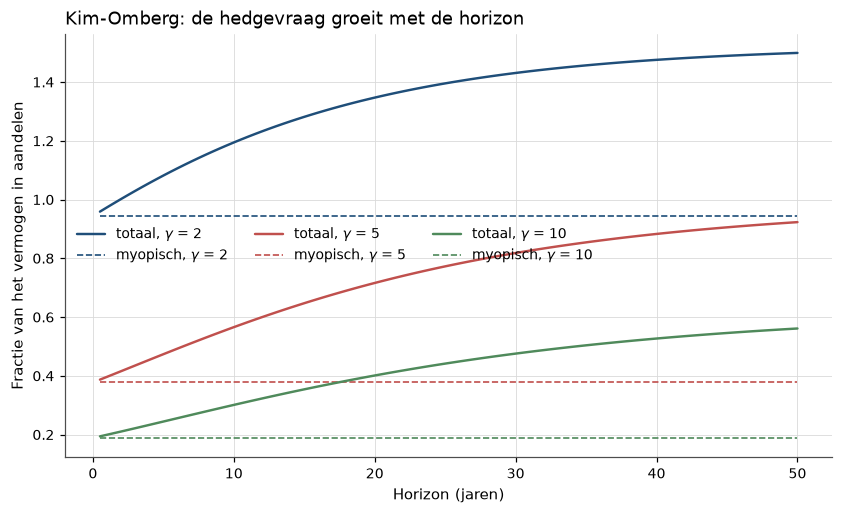

In [4]:
horizon_grid = np.arange(0.5, 50.01, 0.5)
fig, ax = plt.subplots()
for colour, gamma in zip(hap.plotting.COLORS, [2, 5, 10]):
    myopic, hedge = kim_omberg(gamma, horizon_grid, **ko_params)
    ax.plot(horizon_grid, myopic + hedge, color=colour, label=f"totaal, $\\gamma$ = {gamma}")
    ax.plot(horizon_grid, myopic, color=colour, ls="--", lw=1.1,
            label=f"myopisch, $\\gamma$ = {gamma}")
ax.set_xlabel("Horizon (jaren)")
ax.set_ylabel("Fractie van het vermogen in aandelen")
ax.set_title("Kim-Omberg: de hedgevraag groeit met de horizon")
ax.legend(ncol=3)
plt.show()

:::{figure} #cel-merton-icapm-horizon
:label: fig-merton-icapm-horizon
:width: 90%

Optimale aandelenfractie bij de gemiddelde Sharpe-ratio, als functie van de
horizon. De stippellijnen zijn de myopische vraag
$\lambda/(\gamma\sigma)$, die per definitie niet van de horizon afhangt; de
getrokken lijnen tellen de hedgevraag erbij op. Het verschil begint bij nul
voor een belegger zonder toekomst, groeit snel over de eerste tien à twintig jaar
en vlakt af wanneer de horizon ruim voorbij de halfwaardetijd van de
dividendopbrengst ligt ($\log 2/\kappa \approx 8$ jaar). Relatief is de hedgevraag
het grootst voor de meest risicomijdende belegger.
:::

### Controle: dezelfde oplossing op een rooster

Kim-Omberg is een continue-tijdmodel met een benaderde vertaling van een
jaarlijks VAR. Om te zien of die vertaling klopt, lossen we het discrete
probleem ook direct op, zoals {cite:t}`Barberis2000` het deed: jaarlijkse
herbalancering, een rooster van 21 punten voor de dividendopbrengst, en per
roosterpunt en per jaar een maximalisatie van

$$
Q(z, k) = \max_{w\in[0,\,0{,}99]}\ \E\Big[\big((1-w)e^{r^f} + w\,e^{r^f + r^{e}_{k+1}}\big)^{1-\gamma}\,Q(z_{k+1}, k+1)\Big],
\qquad Q(\cdot, K) = 1 ,
$$

achterwaarts in de tijd. Dit is dezelfde recursie als in het bewijs van
[](#thm-merton-icapm-samuelson), maar nu hangt $Q$ van de toestand af en mag
hij daarom niet buiten de verwachting. De verwachting benaderen we met 5000
trekkingen, de maximalisatie met bisectie op de eerste-ordevoorwaarde (de
doelfunctie is concaaf in $w$), en $Q$ tussen roosterpunten lineair.

In [5]:
def solve_rebalancing(gamma, n_years, draw, sd_z, rf=0.02, z0=(0.0,), n_grid=21, n_bisect=20):
    """Backward induction for an annually rebalancing CRRA investor.

    `draw(grid)` returns arrays (log excess return, next state), both of shape
    (n_grid, n_draws), conditional on each grid point. Returns the optimal
    stock share at the states `z0` for horizons 1, ..., n_years.
    """
    grid = np.linspace(-3 * sd_z, 3 * sd_z, n_grid)
    log_excess, z_next = draw(grid)
    gross_excess = np.exp(log_excess)
    Q, shares = np.ones(n_grid), []
    for _ in range(n_years):
        Q_next = np.interp(z_next, grid, Q)
        lo, hi = np.zeros(n_grid), np.full(n_grid, 0.99)
        for _ in range(n_bisect):
            mid = (lo + hi) / 2
            growth = 1 - mid[:, None] + mid[:, None] * gross_excess
            slope = (growth ** (-gamma) * (gross_excess - 1) * Q_next).mean(axis=1)
            lo, hi = np.where(slope > 0, mid, lo), np.where(slope > 0, hi, mid)
        w = (lo + hi) / 2
        growth = np.exp(rf) * (1 - w[:, None] + w[:, None] * gross_excess)
        Q = (growth ** (1 - gamma) * Q_next).mean(axis=1)
        shares.append(np.interp(z0, grid, w))
    return np.array(shares)


def normal_shocks(s1, s2, rho, n_draws):
    cov = np.array([[s1**2, rho * s1 * s2], [rho * s1 * s2, s2**2]])
    return rng.standard_normal((n_draws, 2)) @ np.linalg.cholesky(cov).T


p = illustrative
shocks = normal_shocks(p["s1"], p["s2"], p["rho"], 5000)
sd_z = p["s2"] / np.sqrt(1 - p["phi"] ** 2)
known = lambda grid: (p["a"] + p["b"] * grid[:, None] + shocks[:, 0],
                      p["phi"] * grid[:, None] + shocks[:, 1])

check_horizons = [1, 2, 5, 10, 20]
check = {}
for gamma in [5, 10]:
    grid_share = solve_rebalancing(gamma, 20, known, sd_z)[:, 0]
    myopic, hedge = kim_omberg(gamma, check_horizons, **ko_params)
    check[f"rooster, gamma = {gamma}"] = grid_share[np.array(check_horizons) - 1]
    check[f"Kim-Omberg, gamma = {gamma}"] = myopic + hedge
pd.DataFrame(check, index=[f"H = {h}" for h in check_horizons]).T.round(3)

,H = 1,H = 2,H = 5,H = 10,H = 20
"rooster, gamma = 5",0.394,0.414,0.474,0.568,0.709
"Kim-Omberg, gamma = 5",0.397,0.416,0.474,0.566,0.716
"rooster, gamma = 10",0.196,0.207,0.241,0.297,0.385
"Kim-Omberg, gamma = 10",0.200,0.211,0.245,0.301,0.401


De twee methoden verschillen in hoe ze de tijd behandelen — de ene herbalanceert
één keer per jaar, de andere continu — en in hoe ze het log-rendement vertalen,
maar ze geven dezelfde vorm en vrijwel hetzelfde niveau. Bij $\gamma = 5$
stijgt de roosteroplossing van 0,394 naar 0,709 over twintig jaar, Kim-Omberg
van 0,397 naar 0,716; bij $\gamma = 10$ is het verschil op twintig jaar 1,6
procentpunt (0,385 tegen 0,401). Dat kleine verschil is de prijs van jaarlijkse
in plaats van continue herbalancering, plus de ruis van 5000 trekkingen. Daarmee hebben we twee
onafhankelijke implementaties van dezelfde theorie die elkaar bevestigen. Voor
$\gamma = 2$ doen we de vergelijking niet: daar wil de belegger meer dan 100% in
aandelen en bindt de restrictie $w \le 0{,}99$ die {cite:t}`Barberis2000` oplegt.

### Wat een eeuw data over de hedgevraag zegt

Alles hierboven veronderstelde dat de belegger $b$, $\phi$ en $\rho$ kent. Dat doet
hij niet. Hij heeft, in het beste geval, een eeuw jaarcijfers. We trekken daarom
1000 steekproeven van 100 jaar uit het VAR, schatten per steekproef de parameters
met OLS, en rekenen de Kim-Omberg-allocatie voor een belegger met $\gamma = 5$ en
een horizon van twintig jaar uit alsof de schatting de waarheid is.

In [6]:
def ols_var(r_next, z):
    """OLS of the two-equation VAR; columns of the inputs are independent samples.

    z has length n (the state at t = 0, ..., n-1); r_next has length n-1 and
    r_next[t] is the return earned between t and t+1. Returns intercepts,
    slopes, residual std devs, residual correlation and the standard error of
    the return slope.
    """  # TODO: naar hap.stats
    x, y1, y2 = z[:-1], r_next, z[1:]
    xd = x - x.mean(axis=0)
    sxx = (xd**2).sum(axis=0)
    b = (xd * (y1 - y1.mean(axis=0))).sum(axis=0) / sxx
    phi = (xd * (y2 - y2.mean(axis=0))).sum(axis=0) / sxx
    e1 = y1 - y1.mean(axis=0) - b * xd
    e2 = y2 - y2.mean(axis=0) - phi * xd
    n = len(x)
    s1, s2 = np.sqrt((e1**2).sum(axis=0) / (n - 2)), np.sqrt((e2**2).sum(axis=0) / (n - 2))
    rho = (e1 * e2).sum(axis=0) / ((n - 2) * s1 * s2)
    a = y1.mean(axis=0) - b * x.mean(axis=0)
    c = y2.mean(axis=0) - phi * x.mean(axis=0)
    return {"a": a, "b": b, "c": c, "phi": phi, "s1": s1, "s2": s2, "rho": rho,
            "se_b": s1 / np.sqrt(sxx)}


n_samples, n_years, burn = 1000, 100, 200
z = np.zeros(n_samples)
z_path, r_path = [], []
for t in range(burn + n_years + 1):
    eps = normal_shocks(p["s1"], p["s2"], p["rho"], n_samples)
    r_next = p["a"] + p["b"] * z + eps[:, 0]
    if t >= burn:
        z_path.append(z)
        r_path.append(r_next)
    z = p["phi"] * z + eps[:, 1]
z_path, r_path = np.array(z_path), np.array(r_path)

est = ols_var(r_path[:-1], z_path)
est_cont = var_to_continuous(est["a"] + est["b"] * z_path[:-1].mean(axis=0), est["b"],
                             np.minimum(est["phi"], 0.995), est["s1"], est["s2"], est["rho"])
myopic_hat, hedge_hat = kim_omberg(5, [20], **est_cont)
myopic_true, hedge_true = kim_omberg(5, [20], **ko_params)

pd.DataFrame(
    {
        "waarheid": [p["b"], p["phi"], float(hedge_true[0]), float(myopic_true[0])],
        "gemiddelde schatting": [est["b"].mean(), est["phi"].mean(),
                                 hedge_hat[0].mean(), myopic_hat[0].mean()],
        "5%-kwantiel": [np.quantile(est["b"], 0.05), np.quantile(est["phi"], 0.05),
                        np.quantile(hedge_hat[0], 0.05), np.quantile(myopic_hat[0], 0.05)],
        "95%-kwantiel": [np.quantile(est["b"], 0.95), np.quantile(est["phi"], 0.95),
                         np.quantile(hedge_hat[0], 0.95), np.quantile(myopic_hat[0], 0.95)],
    },
    index=["b", "phi", "hedgevraag (H = 20, gamma = 5)", "myopische vraag (gamma = 5)"],
).round(3)

,waarheid,gemiddelde schatting,5%-kwantiel,95%-kwantiel
b,0.080,0.124,0.042,0.247
phi,0.920,0.880,0.781,0.948
"hedgevraag (H = 20, gamma = 5)",0.339,0.450,0.143,0.850
myopische vraag (gamma = 5),0.378,0.383,0.264,0.512


In [7]:
print(f"fractie steekproeven met t(b) > 1.96: {np.mean(est['b'] / est['se_b'] > 1.96):.1%}")
print(f"fractie steekproeven met hedgevraag < 0: {np.mean(hedge_hat[0] < 0):.1%}")

fractie steekproeven met t(b) > 1.96: 55.5%
fractie steekproeven met hedgevraag < 0: 0.1%


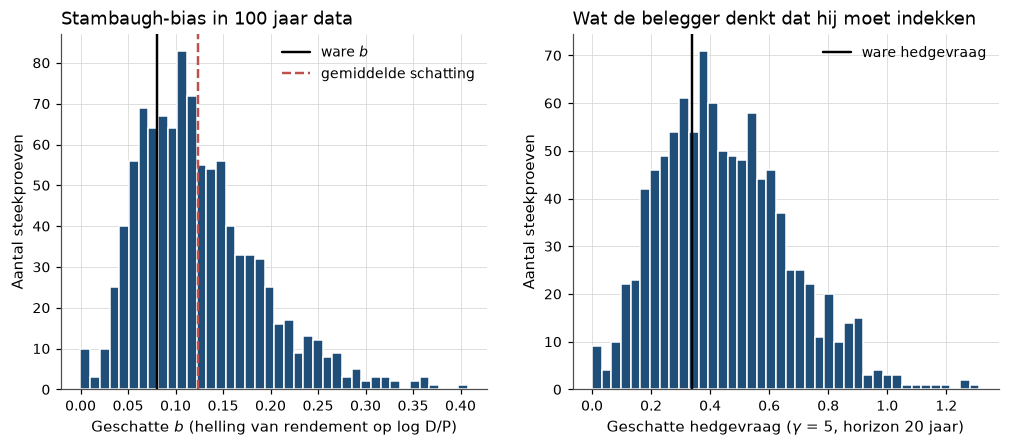

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(est["b"], bins=40, edgecolor="white")
axes[0].axvline(p["b"], color="black", lw=1.6, label="ware $b$")
axes[0].axvline(est["b"].mean(), color=hap.plotting.COLORS[1], ls="--", lw=1.6,
                label="gemiddelde schatting")
axes[0].set_xlabel("Geschatte $b$ (helling van rendement op log D/P)")
axes[0].set_ylabel("Aantal steekproeven")
axes[0].set_title("Stambaugh-bias in 100 jaar data")
axes[0].legend()
axes[1].hist(hedge_hat[0], bins=40, edgecolor="white")
axes[1].axvline(float(hedge_true[0]), color="black", lw=1.6, label="ware hedgevraag")
axes[1].set_xlabel("Geschatte hedgevraag ($\\gamma$ = 5, horizon 20 jaar)")
axes[1].set_ylabel("Aantal steekproeven")
axes[1].set_title("Wat de belegger denkt dat hij moet indekken")
axes[1].legend()
plt.show()

:::{figure} #cel-merton-icapm-steekproef
:label: fig-merton-icapm-steekproef
:width: 100%

Links: de verdeling van de OLS-schatter van $b$ over 1000 steekproeven van 100
jaar. Het gemiddelde ligt duidelijk boven de ware waarde van 0,08, omdat de
schatter van $\phi$ naar beneden vertekend is en de schokken sterk negatief
gecorreleerd zijn — de bias van {cite:t}`Stambaugh1999`. Rechts: de hedgevraag
die een belegger uit zijn eigen steekproef zou afleiden. Dezelfde wereld levert
steekproeven op waarin de belegger minder dan de helft van de ware hedgevraag
koopt, en steekproeven waarin hij er tweeënhalf keer zoveel van koopt.
:::

Dit is motief 1 in zijn dynamische vorm. De ware wereld heeft een hedgevraag van
0,339, maar een belegger met een eeuw data komt in 90% van de steekproeven
ergens tussen 0,143 en 0,850 uit, en maar in 55,5% van de steekproeven is
$\hat b$ op het 5%-niveau significant — terwijl de voorspelbaarheid in deze
wereld per constructie echt is. De spreiding komt uit de grootheden die over
*verwachte rendementen* gaan: $\hat b$ voor de hedgevraag en $\hat a$ voor de
myopische vraag, die zelf van 0,264 tot 0,512 loopt. De tweede momenten —
volatiliteiten en $\rho$ — zijn over een eeuw goed bepaald. Bovendien is het
gemiddelde van de schattingen te hoog: de Stambaugh-bias duwt $\hat b$ van 0,080
naar gemiddeld 0,124, en de geschatte hedgevraag gaat mee, naar gemiddeld 0,450.
Een belegger die zijn OLS-schatting gelooft, overschat gemiddeld hoeveel hij zich
moet indekken.

{cite:t}`Barberis2000` trok daaruit de consequentie. Een belegger die weet dat
zijn $b$ onzeker is, moet niet de puntschatting in het model stoppen, maar het
verwachte nut middelen over de posterior verdeling van alle parameters. Dat heeft
twee effecten, en die werken dezelfde kant op: onzekerheid over het gemiddelde
rendement maakt de verdeling van het cumulatieve rendement op lange horizons
breder (de variantie groeit sneller dan lineair), en onzekerheid over $b$ maakt
onzeker of mean reversion er überhaupt is. We passen die methode hieronder toe
op de echte data.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Nicholas Barberis, *Investing for the Long Run when Returns Are
Predictable*, Journal of Finance 2000 {cite}`Barberis2000`; en John Campbell en
Luis Viceira, *Consumption and Portfolio Decisions when Expected Returns are Time
Varying*, Quarterly Journal of Economics 1999 {cite}`CampbellViceira1999`.

**Wat.** (1) Barberis' tabel II, linkerpaneel: het VAR van het maandelijkse
log excess rendement op de dividendopbrengst, juni 1952 – december 1995. Hij
rapporteert (posterior gemiddelde en standaarddeviatie) een helling van 0,5118
(0,2129), een autoregressieve coëfficiënt van de dividendopbrengst van 0,9774
(0,0091), een residuvariantie van het rendement van 0,0017 (0,0001) en een
correlatie tussen de schokken van −0,9351. (2) De horizonallocaties van zijn
figuur 5 en de conclusie van Campbell en Viceira dat de hedgevraag de vraag naar
aandelen "greatly increase[s], and may even double" voor beleggers met
risicoaversie boven één. (3) Barberis' conclusie dat met parameteronzekerheid "the
allocation lines are much flatter and the hedging demands much smaller" (p. 256),
en uit zijn abstract dat "a long-horizon investor who ignores it may
overallocate to stocks by a sizeable amount"; voor een koop-en-houdbelegger met
$A = 10$ kan dat oplopen tot "more than 30 percent at a 10-year horizon" (p. 246).

**Data hier.** Goyal-Welch via `hap.data.goyal_welch`: maandelijks (1) en
jaarlijks (2)–(3). Rendement: $\log(1 + \texttt{CRSP\_SPvw}) - \log(1 + \texttt{Rfree})$;
toestand: de dividendopbrengst $D_{12}/P$ (maandelijks, niveau, zoals Barberis)
of $\log D_{12} - \log P$ (jaarlijks). Jaarlijkse steekproef: rendementen 1927–2025
op de dividendopbrengst van het jaar ervoor.

**Verschil met het origineel.** Barberis gebruikt de value-weighted NYSE-index van
CRSP en schatkistpapier van Ibbotson; Goyal-Welch geeft het value-weighted
S&P 500-rendement van CRSP. Barberis werkt maandelijks met jaarlijkse
herbalancering en een horizon tot tien jaar; wij werken jaarlijks tot twintig jaar.
Campbell en Viceira gebruiken Epstein-Zin-nut met consumptie en een
log-lineaire benadering; wij gebruiken CRRA over eindvermogen en de exacte
Kim-Omberg-oplossing plus een roosteroplossing. Barberis leert niet bij in de
dynamische berekening met parameteronzekerheid, en wij ook niet.

**Verwachte afwijking.** (1) Het teken en de orde van grootte van alle
VAR-coëfficiënten moeten overeenkomen: een positieve helling binnen ongeveer
één standaardfout van 0,51, een $\phi$ rond 0,98 en een correlatie tussen −0,9 en
−1. Een negatieve helling of een positieve correlatie betekent een fout in de
code. (2) Op de eeuwsteekproef moet de hedgevraag voor $\gamma > 1$ positief zijn
en met de horizon toenemen; hoe groot hangt af van $\hat b$, en omdat de
voorspelkracht van de dividendopbrengst na 1995 is ingezakt, verwachten we een
kleinere hedgevraag dan de verdubbeling van Campbell en Viceira. (3) Met
parameteronzekerheid moet de allocatie op elke horizon lager liggen dan zonder, en
minder gevoelig zijn voor de begintoestand; het verschil moet groter zijn in een
kortere steekproef.
```

### Barberis' VAR

In [9]:
gw_monthly = hap_data.goyal_welch("monthly")
monthly = pd.DataFrame(
    {
        "excess": np.log1p(gw_monthly["CRSP_SPvw"]) - np.log1p(gw_monthly["Rfree"]),
        "dy": gw_monthly["D12"] / gw_monthly["Index"],
    }
).loc["1952-06":"1995-12"]

# z[t] is the dividend yield at the end of month t, r_next[t] the return over month t+1
mon = ols_var(monthly["excess"].to_numpy()[1:, None], monthly["dy"].to_numpy()[:, None])
mon = {k: float(v[0]) for k, v in mon.items()}
dy_lag = monthly["dy"].to_numpy()[:-1]
se_phi = mon["s2"] / np.sqrt(((dy_lag - dy_lag.mean()) ** 2).sum())

pd.DataFrame(
    {
        "Barberis (2000), tabel II": [0.5118, 0.2129, 0.9774, 0.0091, 0.0017, -0.9351],
        "hier (OLS)": [mon["b"], mon["se_b"], mon["phi"], se_phi, mon["s1"] ** 2, mon["rho"]],
    },
    index=["helling rendement op D/P", "  standaardfout", "phi (D/P op D/P)", "  standaardfout",
           "residuvariantie rendement", "correlatie schokken"],
).round(4)

,"Barberis (2000), tabel II",hier (OLS)
helling rendement op D/P,0.5118,0.4058
standaardfout,0.2129,0.1993
phi (D/P op D/P),0.9774,0.9805
standaardfout,0.0091,0.0081
residuvariantie rendement,0.0017,0.0017
correlatie schokken,-0.9351,-0.9677


De ordening en de orde van grootte kloppen. Onze helling is 0,406 met een
standaardfout van 0,199, tegen Barberis' 0,5118 (0,2129): een verschil van een
halve standaardfout, bij een andere index. De persistentie is 0,981 tegen 0,977,
de residuvariantie is gelijk tot op de gerapporteerde decimaal, en de correlatie
tussen de schokken is −0,968 tegen −0,935. Twee dingen staan er ook: met een
flat prior valt het posterior gemiddelde samen met OLS, zodat onze kolom de
vergelijkbare grootheid is; en ook in de steekproef van Barberis zelf is de helling
maar net twee standaardfouten van nul verwijderd. Op die ene $t$-waarde van rond
de twee rust de hele literatuur over horizoneffecten.

### Horizonallocaties op een eeuw jaarcijfers

In [10]:
gw_annual = hap_data.goyal_welch("annual").loc["1926":"2025"]
log_dp = gw_annual["dp"].to_numpy()
excess_next = (np.log1p(gw_annual["CRSP_SPvw"]) - np.log1p(gw_annual["Rfree"])).to_numpy()[1:]
dp_mean = log_dp[:-1].mean()
z_annual = log_dp - dp_mean

ann = ols_var(excess_next[:, None], z_annual[:, None])
ann = {k: float(v[0]) for k, v in ann.items()}
rf_annual = float(np.log1p(gw_annual["Rfree"]).mean())
ann_cont = var_to_continuous(ann["a"], ann["b"], ann["phi"], ann["s1"], ann["s2"], ann["rho"])

pd.DataFrame(
    {"schatting": [ann["a"], ann["b"], ann["se_b"], ann["b"] / ann["se_b"], ann["phi"],
                   ann["s1"], ann["s2"], ann["rho"], rf_annual, z_annual[-1]]},
    index=["a (gem. log excess rendement)", "b", "  standaardfout", "  t-waarde", "phi",
           "sd rendementsschok", "sd D/P-schok", "correlatie schokken",
           "gem. log risicovrije rente", "log D/P eind 2025 min gemiddelde"],
).round(4)

,schatting
a (gem. log excess rendement),0.0652
b,0.0423
standaardfout,0.0394
t-waarde,1.0727
phi,0.9239
sd rendementsschok,0.1936
sd D/P-schok,0.2122
correlatie schokken,-0.8561
gem. log risicovrije rente,0.0331
log D/P eind 2025 min gemiddelde,-1.0338


Over de hele eeuw is de voorspelkracht van de dividendopbrengst zwak: een
helling van 0,042 met een standaardfout van 0,039, een $t$-waarde van 1,07. De
persistentie (0,924) en de sterk negatieve correlatie tussen de schokken
(−0,856) zijn er nog wel. Dat is precies het patroon uit de simulatie: de tweede
momenten zijn goed bepaald, het verwachte rendement niet.

In [11]:
horizons = [1, 5, 10, 20, 50]
cv_table = {}
for gamma in [2, 5, 10]:
    myopic, hedge = kim_omberg(gamma, horizons, **ann_cont)
    cv_table[(f"gamma = {gamma}", "myopisch")] = myopic
    cv_table[(f"gamma = {gamma}", "hedge")] = hedge
    cv_table[(f"gamma = {gamma}", "totaal / myopisch")] = (myopic + hedge) / myopic
pd.DataFrame(cv_table, index=[f"H = {h}" for h in horizons]).T.round(3)

H = 1  H = 5  H = 10  H = 20  H = 50
gamma = 2  myopisch           1.120  1.120   1.120   1.120   1.120
           hedge              0.023  0.104   0.186   0.294   0.400
           totaal / myopisch  1.020  1.093   1.166   1.262   1.357
gamma = 5  myopisch           0.448  0.448   0.448   0.448   0.448
           hedge              0.015  0.071   0.132   0.223   0.336
           totaal / myopisch  1.033  1.157   1.294   1.499   1.751
gamma = 10 myopisch           0.224  0.224   0.224   0.224   0.224
           hedge              0.008  0.040   0.077   0.134   0.211
           totaal / myopisch  1.037  1.181   1.343   1.598   1.943

Zelfs met een helling die statistisch niet van nul te onderscheiden is, geeft de
theorie een hedgevraag van betekenis. Bij $\gamma = 5$ is de myopische vraag 0,448,
en de hedgevraag is 0,132 bij tien jaar en 0,223 bij twintig jaar: een belegger
met een horizon van twintig jaar houdt de helft meer aandelen dan een myopische
belegger. Bij vijftig jaar is de verhouding 1,75 voor $\gamma = 5$ en 1,94 voor
$\gamma = 10$. De voorspelling van {cite:t}`CampbellViceira1999` — flink meer, bij
hoge risicoaversie bijna het dubbele — komt dus ook hier uit, maar bij de
horizons die voor een pensioenbelegger realistisch zijn (tien tot twintig jaar)
blijft zij onder de verdubbeling, zoals het replicatieblok verwachtte. De reden
dat de hedgevraag zo groot is bij zo'n zwakke helling, is de combinatie van
$\rho \approx -0{,}86$ en een halfwaardetijd van de dividendopbrengst van ruim
acht jaar: een klein maar zeer persistent effect telt op over een lange horizon.

### Parameteronzekerheid à la Barberis

Nu de stap van {cite:t}`Barberis2000`. Met een flat prior
$p(\mathbf{C}, \boldsymbol{\Sigma}) \propto |\boldsymbol{\Sigma}|^{-3/2}$ op de
coëfficiëntenmatrix $\mathbf{C}$ en de covariantiematrix $\boldsymbol{\Sigma}$ van het
VAR is de posterior standaard: $\boldsymbol{\Sigma}$ is invers-Wishart met $T - 3$
vrijheidsgraden en schaalmatrix $\mathbf{S} = \mathbf{E}'\mathbf{E}$, en gegeven
$\boldsymbol{\Sigma}$ is $\mathrm{vec}(\mathbf{C})$ normaal rond de OLS-schatting met
covariantie $\boldsymbol{\Sigma}\otimes(\mathbf{X}'\mathbf{X})^{-1}$ — Barberis'
uitdrukkingen onder zijn vergelijking (16). We trekken 5000 parametersets,
trekken per set één schok, en gebruiken die trekkingen als de voorspellende
verdeling in dezelfde roosteroplossing als hierboven. Zoals bij Barberis houdt
de belegger zijn posterior vast over de horizon: hij weet dat hij de parameters
niet kent, maar houdt geen rekening met wat hij later zal leren.

In [12]:
def posterior_predictive(r_next, z, n_draws):
    """Draws of (a, b, c, phi) and one VAR shock per draw under a flat prior (Barberis 2000)."""
    X = np.column_stack([np.ones(len(z) - 1), z[:-1]])
    Y = np.column_stack([r_next, z[1:]])
    C_hat = np.linalg.solve(X.T @ X, X.T @ Y)
    resid = Y - X @ C_hat
    Sigma = stats.invwishart(df=len(Y) - 3, scale=resid.T @ resid).rvs(n_draws, random_state=rng)
    L_sigma = np.linalg.cholesky(Sigma)
    L_x = np.linalg.cholesky(np.linalg.inv(X.T @ X))
    C = C_hat + np.einsum("ij,njk,nlk->nil", L_x, rng.standard_normal((n_draws, 2, 2)), L_sigma)
    eps = np.einsum("nij,nj->ni", L_sigma, rng.standard_normal((n_draws, 2)))
    return C, eps


C_draws, eps_draws = posterior_predictive(excess_next, z_annual, 5000)
pd.DataFrame(
    {"gemiddelde": [C_draws[:, 1, 0].mean(), C_draws[:, 1, 1].mean()],
     "standaarddeviatie": [C_draws[:, 1, 0].std(), C_draws[:, 1, 1].std()],
     "kans < 0": [np.mean(C_draws[:, 1, 0] < 0), np.mean(C_draws[:, 1, 1] < 0)],
     "kans > 1": [np.mean(C_draws[:, 1, 0] > 1), np.mean(C_draws[:, 1, 1] > 1)]},
    index=["b (posterior)", "phi (posterior)"],
).round(3)

,gemiddelde,standaarddeviatie,kans < 0,kans > 1
b (posterior),0.042,0.040,0.141,0.000
phi (posterior),0.923,0.044,0.000,0.042


De posterior van $b$ heeft een gemiddelde van 0,04 en een standaarddeviatie van
dezelfde grootte; een op de zeven trekkingen heeft een *negatieve* helling,
een wereld waarin een hoge dividendopbrengst lage rendementen voorspelt. Een paar
procent van de trekkingen heeft $\phi > 1$, een dividendopbrengst die niet naar
een gemiddelde terugkeert. Beide soorten werelden ondermijnen de reden om zich
in te dekken.

In [13]:
shocks_ann = normal_shocks(ann["s1"], ann["s2"], ann["rho"], 5000)
sd_z_ann = ann["s2"] / np.sqrt(1 - ann["phi"] ** 2)
start_states = (0.0, z_annual[-1])

point = lambda grid: (ann["a"] + ann["b"] * grid[:, None] + shocks_ann[:, 0],
                      ann["c"] + ann["phi"] * grid[:, None] + shocks_ann[:, 1])
share_point = solve_rebalancing(5, 20, point, sd_z_ann, rf=rf_annual, z0=start_states)

In [14]:
predictive = lambda grid: (C_draws[:, 0, 0] + C_draws[:, 1, 0] * grid[:, None] + eps_draws[:, 0],
                           C_draws[:, 0, 1] + C_draws[:, 1, 1] * grid[:, None] + eps_draws[:, 1])
share_bayes = solve_rebalancing(5, 20, predictive, sd_z_ann, rf=rf_annual, z0=start_states)

show = np.array([1, 2, 5, 10, 15, 20])
pd.DataFrame(
    {
        ("D/P op gemiddelde", "parameters bekend"): share_point[show - 1, 0],
        ("D/P op gemiddelde", "parameteronzekerheid"): share_bayes[show - 1, 0],
        ("D/P zoals eind 2025", "parameters bekend"): share_point[show - 1, 1],
        ("D/P zoals eind 2025", "parameteronzekerheid"): share_bayes[show - 1, 1],
    },
    index=[f"H = {h}" for h in show],
).round(3)

D/P op gemiddelde                      D/P zoals eind 2025  \
       parameters bekend parameteronzekerheid   parameters bekend   
H = 1              0.459                0.440               0.222   
H = 2              0.474                0.454               0.229   
H = 5              0.517                0.496               0.254   
H = 10             0.580                0.555               0.295   
H = 15             0.630                0.601               0.333   
H = 20             0.668                0.635               0.364   

                             
       parameteronzekerheid  
H = 1                 0.210  
H = 2                 0.217  
H = 5                 0.241  
H = 10                0.280  
H = 15                0.316  
H = 20                0.345

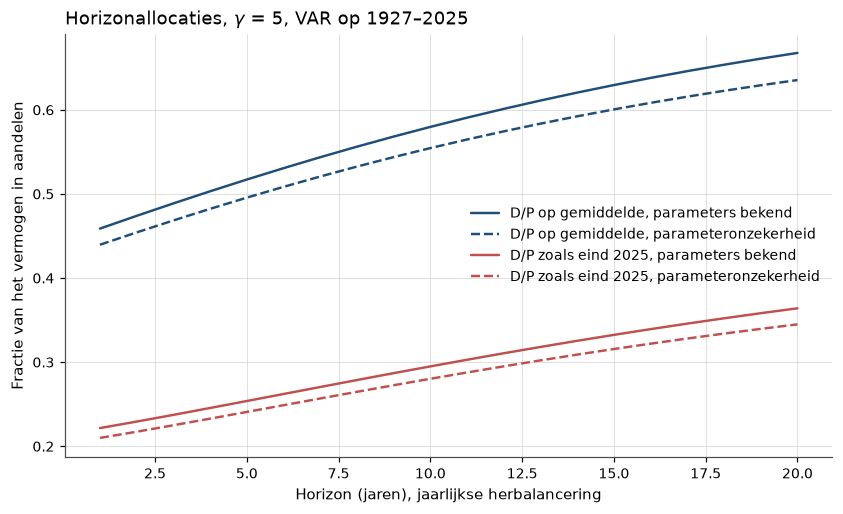

In [15]:
years = np.arange(1, 21)
fig, ax = plt.subplots()
for j, (label, colour) in enumerate([("D/P op gemiddelde", hap.plotting.COLORS[0]),
                                     ("D/P zoals eind 2025", hap.plotting.COLORS[1])]):
    ax.plot(years, share_point[:, j], color=colour, label=f"{label}, parameters bekend")
    ax.plot(years, share_bayes[:, j], color=colour, ls="--",
            label=f"{label}, parameteronzekerheid")
ax.set_xlabel("Horizon (jaren), jaarlijkse herbalancering")
ax.set_ylabel("Fractie van het vermogen in aandelen")
ax.set_title("Horizonallocaties, $\\gamma$ = 5, VAR op 1927–2025")
ax.legend()
plt.show()

:::{figure} #cel-merton-icapm-barberis
:label: fig-merton-icapm-barberis
:width: 90%

Optimale aandelenfractie voor een belegger die elk jaar herbalanceert, met de
VAR-parameters vast op hun schatting (getrokken) of met de posterior verdeling
geïntegreerd (gestreept), vertrekkend vanaf een gemiddelde dividendopbrengst
(blauw) of vanaf de uitzonderlijk lage dividendopbrengst van eind 2025 (rood).
Het horizoneffect is er in alle vier de gevallen: de lijn stijgt. Parameteronzekerheid
verlaagt de allocatie op elke horizon en haalt een deel van de stijging weg.
:::

De replicatie bevestigt Barberis' richting en valt in grootte lager uit. Met de
dividendopbrengst op haar gemiddelde stijgt de allocatie zonder
parameteronzekerheid van 0,459 bij één jaar naar 0,668 bij twintig jaar; met
parameteronzekerheid van 0,440 naar 0,635. Op elke horizon ligt de gestreepte
lijn lager, en het absolute verschil groeit van twee naar drie procentpunt. Het teken en
de ordening zijn dus zoals voorspeld. Maar de "much flatter" lijnen van Barberis'
figuur 5 en zijn overallocatie van meer dan dertig procentpunt zien we hier niet.
Dat heeft een eenvoudige verklaring, die zelf motief 1 is: Barberis' dynamische
figuur 5 gebruikt de tienjaarssteekproef 1986–1995, en zijn koop-en-houdgetal van
dertig procentpunt komt uit 44 jaar maanddata met een voorspelkracht die veel
sterker leek dan die van onze eeuw. Wij hebben honderd jaar, en de posterior van
de onbekende gemiddelden is daardoor smaller. In oefening
[](#ex-merton-icapm-3) herhalen we de berekening op de laatste dertig jaar, en
daar is het effect van parameteronzekerheid wel groot.

De dividendopbrengst van eind 2025 is de laagste van de hele steekproef, bijna
twee standaardafwijkingen onder het gemiddelde. Een belegger die de VAR gelooft,
verwacht daarom lage rendementen en houdt bij een horizon van één jaar maar 0,22
in aandelen, tegen 0,46 bij een gemiddelde toestand. Ook dat getal hangt aan
dezelfde helling met een $t$-waarde van één.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Merton maakte van portefeuillekeuze een dynamisch
probleem en van asset pricing een theorie met meer dan één bron van risico. Uit
[](#thm-merton-icapm-samuelson) volgt dat "jong zijn" op zich geen reden is voor
meer aandelen; uit [](#thm-merton-icapm-hedging) volgt wat dan wél een reden is:
het indekken van veranderende vooruitzichten. Beide uitspraken zijn stellingen,
en de hele levenscyclusliteratuur, de indeling in strategische en tactische
allocatie, en de rechtvaardiging van langlopende obligaties voor
pensioenfondsen staan erop. Het ICAPM gaf elk later meerfactormodel een
theoretische vergunning: een factor is beprijsd als hij de toekomstige
beleggingskansen voorspelt. En de continue-tijdtechniek — Itô, HJB, verificatie
— werd de gemeenschappelijke taal van optiewaardering, termijnstructuurmodellen en
moderne macrofinanciering.

**Waar het breekt.** Niet in de wiskunde, maar opnieuw in de invoer. De
hedgevraag is een functie van een helling van rendement op een voorspeller, en die
helling is een uitspraak over een verwacht rendement. In onze replicatie is die
helling over 1927–2025 0,042 met een $t$-waarde van 1,07, en toch zegt de theorie dat
een belegger met $\gamma = 5$ en een horizon van twintig jaar 0,223 extra in
aandelen moet houden, de helft van zijn myopische positie. De simulatie liet zien
dat een eeuw data bij een ware helling van 0,08 geschatte hedgevragen oplevert die
van minder dan de helft tot tweeënhalf keer de waarheid lopen, met een
systematische opwaartse bias. Merton zelf liet in 1980 zien waarom: het verwachte marktrendement
is uit een tijdreeks alleen te leren met een lange kalenderperiode, hoe vaak u ook
meet {cite}`Merton1980`. Een tweede breuk is theoretisch: het ICAPM noemt de
staatsvariabelen niet, en een model dat elke voorspellende variabele toelaat als
factor, laat zich niet verwerpen.

**Risico of vergissing?** Dat de dividendopbrengst rendementen voorspelt, is het
feit waar de hele hedgevraag op rust, en het laat twee lezingen toe. De
Chicago-lezing: verwachte rendementen variëren omdat de beprijzing van risico
varieert. Na een crash zijn beleggers armer en risicomijdender, eisen ze een hogere
premie, en is een lage prijs het rationele gevolg; de langetermijnbelegger die dan
bijkoopt, draagt beprijsd risico en wordt daarvoor betaald, en zijn hedgevraag is
precies Mertons verzekeringsmotief. De Yale-lezing: prijzen schieten door, na een
hausse te hoog en na een crash te laag, en de dividendopbrengst voorspelt omdat de
vergissing zich herstelt. Dan is dezelfde extra aandelenpositie geen verzekering
maar een contrair beleggingsidee — de belegger rekent erop dat hij iets weet wat de
prijs niet weet, en het praktijkmotief van Santa-Clara waarschuwt precies daarvoor.
Het VAR maakt geen onderscheid: beide lezingen voorspellen een positieve $b$ en een
negatieve $\rho$. Wat ze zou scheiden, is of de variatie in verwachte rendementen
samengaat met variatie in het marginale nut van beleggers — met consumptie, met
recessies — en dat is de toets die Breeden mogelijk maakte. Tot die toets overtuigt,
blijft de keuze aan de lezer.

**Wat er daarna kwam.** Merton liet de identiteit van de factoren open; Ross liet
in 1976 zien dat je voor een factormodel helemaal geen voorkeuren nodig hebt, alleen
de afwezigheid van arbitrage: zie [](#03-11-apt-no-arbitrage).

## Oefeningen

:::{exercise}
:label: ex-merton-icapm-1

**De lange horizon in gesloten vorm.** Neem [](#eq-merton-icapm-riccati).

1. Laat zien dat de stationaire waarde $C_\infty = \lim_{\tau\to\infty} C(\tau)$
   (als die bestaat) een wortel is van
   $\sigma_\lambda^2(1 + \delta\rho^2)\,C^2 + 2(\delta\rho\sigma_\lambda - \kappa)\,C + \delta = 0$,
   en leid een uitdrukking voor $B_\infty$ af in termen van $C_\infty$.
2. Welke van de twee wortels is de limiet voor $\gamma > 1$? Beargumenteer het
   met het tekenargument uit het bewijs van [](#thm-merton-icapm-kimomberg).
3. Bereken $C_\infty$, $B_\infty$ en de hedgevraag op de oneindige horizon voor
   de illustratieve parameters en $\gamma = 5$, en vergelijk met de Runge-Kutta-oplossing
   bij $\tau = 200$ jaar.
:::

:::{solution} ex-merton-icapm-1
:class: dropdown

**(1)** Stel $C' = 0$ in de eerste vergelijking:
$0 = \delta(1 + 2\rho\sigma_\lambda C + \rho^2\sigma_\lambda^2C^2) - 2\kappa C + \sigma_\lambda^2C^2$.
Groeperen naar machten van $C$ geeft de gevraagde vierkantsvergelijking. Stel
$B' = 0$ in de tweede vergelijking en los op naar $B$:

$$
B_\infty = \frac{\kappa\theta C_\infty}{\kappa - \sigma_\lambda^2 C_\infty - \delta\rho\sigma_\lambda(1 + \rho\sigma_\lambda C_\infty)} .
$$

**(2)** Bij $\gamma > 1$ is $\delta < 0$, dus het product van de wortels
$\delta/(\sigma_\lambda^2(1 + \delta\rho^2))$ is negatief zolang $1 + \delta\rho^2 > 0$:
er is één negatieve en één positieve wortel. $C$ begint in nul, wordt negatief en
kan nul niet meer passeren, dus de limiet is de negatieve wortel,
$C_\infty = \big[(\kappa - \delta\rho\sigma_\lambda) - \sqrt{(\kappa - \delta\rho\sigma_\lambda)^2 - \delta\sigma_\lambda^2(1+\delta\rho^2)}\big]/\big(\sigma_\lambda^2(1 + \delta\rho^2)\big)$.

**(3)**

In [16]:
gamma = 5
delta = (1 - gamma) / gamma
kp = ko_params
quad_a = kp["sig_l"] ** 2 * (1 + delta * kp["rho"] ** 2)
quad_b = 2 * (delta * kp["rho"] * kp["sig_l"] - kp["kappa"])
C_inf = (-quad_b - np.sqrt(quad_b**2 - 4 * quad_a * delta)) / (2 * quad_a)
B_inf = kp["kappa"] * kp["theta"] * C_inf / (
    kp["kappa"] - kp["sig_l"] ** 2 * C_inf
    - delta * kp["rho"] * kp["sig_l"] * (1 + kp["rho"] * kp["sig_l"] * C_inf))
hedge_inf = kp["rho"] * kp["sig_l"] * (B_inf + C_inf * kp["theta"]) / (gamma * kp["sigma"])
myopic_200, hedge_200 = kim_omberg(gamma, [200], **kp)

pd.DataFrame(
    {"waarde": [C_inf, B_inf, hedge_inf, float(hedge_200[0]), float(myopic_200[0])]},
    index=["C oneindig", "B oneindig", "hedgevraag, oneindige horizon",
           "hedgevraag, Runge-Kutta bij 200 jaar", "myopische vraag"],
).round(4)

,waarde
C oneindig,-9.6283
B oneindig,-5.4899
"hedgevraag, oneindige horizon",0.6088
"hedgevraag, Runge-Kutta bij 200 jaar",0.6087
myopische vraag,0.3778


De gesloten vorm en de numerieke oplossing bij 200 jaar vallen samen. De
hedgevraag op oneindige horizon is groter dan de myopische vraag: de
langetermijnbelegger met $\gamma = 5$ houdt in deze wereld ruim het dubbele van
wat Markowitz zou voorschrijven. De oefening laat zien dat het horizoneffect
begrensd is en dat de grens volledig bepaald wordt door vier getallen
($\kappa$, $\theta$, $\sigma_\lambda$, $\rho$), waarvan er twee — $\theta$ en
$\sigma_\lambda$ — verwachte rendementen zijn.
:::

:::{exercise}
:label: ex-merton-icapm-2

**Het teken van de hedgevraag.** Gebruik het toy-voorbeeld met de voorspelbare
periode 2 (na een stijging duur, na een daling goedkoop).

1. Bereken de optimale $w_0$ en de myopische $w$ voor $\gamma \in \{0{,}5;\ 1;\ 2;\ 5;\ 10\}$.
2. Voor welke $\gamma$ is de hedgevraag negatief? Leg met $q_{\text{duur}}$ en
   $q_{\text{goedkoop}}$ uit waarom.
3. Is de hedgevraag *relatief* tot de myopische vraag monotoon in $\gamma$?
:::

:::{solution} ex-merton-icapm-2
:class: dropdown

In [17]:
records = []
for gamma in [0.5, 1.0, 2.0, 5.0, 10.0]:
    row = toy_table(gamma)
    records.append({
        "gamma": gamma,
        "myopisch": row["myopisch (een periode)"],
        "w0 voorspelbaar": row["B: stijging -> duur"],
        "hedgevraag": row["B: stijging -> duur"] - row["myopisch (een periode)"],
        "hedge / myopisch": row["B: stijging -> duur"] / row["myopisch (een periode)"] - 1,
        "q goedkoop": row["q goedkoop"],
        "q duur": row["q duur"],
    })
pd.DataFrame(records).set_index("gamma").round(4)

,myopisch,w0 voorspelbaar,hedgevraag,hedge / myopisch,q goedkoop,q duur
gamma,,,,,,
0.5,3.4722,3.1553,-0.3169,-0.0913,1.0833,1.0
1.0,1.7361,1.7361,0.0000,0.0000,1.0000,1.0
2.0,0.8333,0.8759,0.0426,0.0511,0.9615,1.0
5.0,0.3212,0.3463,0.0251,0.0782,0.9402,1.0
10.0,0.1583,0.1720,0.0137,0.0862,0.9335,1.0


**(2)** Bij $\gamma = 0{,}5$ is de hedgevraag negatief. Voor $\gamma < 1$ is
$1 - \gamma > 0$, en dan betekent een betere toekomst een *hogere*
$q = \E[(1+wR^{e})^{1-\gamma}]$: $q_{\text{goedkoop}} > 1 = q_{\text{duur}}$. Het
marginale nut van vermogen is dan het hoogst in de goedkope toestand, en de
belegger wil vermogen hebben wanneer de kansen goed zijn, niet wanneer ze slecht
zijn. Het aandeel levert het omgekeerde, dus hij houdt minder. Bij $\gamma = 1$
is $q = 1$ in beide toestanden en is de hedgevraag nul; bij $\gamma > 1$ is het
teken positief. Dit is het resultaat van {cite:t}`KimOmberg1996` zoals
{cite:t}`Barberis2000` het samenvat: beleggers met $A > 1$ dekken zich in,
beleggers met $A < 1$ speculeren op de verandering van de kansen.

**(3)** Relatief tot de myopische vraag groeit de hedgevraag met $\gamma$, maar
in absolute termen niet noodzakelijk, omdat de myopische vraag zelf met $1/\gamma$
krimpt. Voor een zeer risicomijdende belegger is indekken het grootste deel van
zijn aandelenpositie. De oefening laat zien dat de hedgevraag geen eigenschap van
het activum is, maar van de wisselwerking tussen het activum en de manier waarop
de belegger over zijn toekomst oordeelt.
:::

:::{exercise}
:label: ex-merton-icapm-3

**Een kortere steekproef.** Barberis liet zien dat parameteronzekerheid zwaarder
weegt naarmate de steekproef korter is. Herhaal de replicatie op de jaarlijkse
Goyal-Welch-data met rendementen over 1996–2025 (dertig jaar), met $\gamma = 10$
(bij $\gamma = 5$ loopt de allocatie in deze steekproef tegen de grens van 99%).

1. Schat het VAR en rapporteer $\hat b$, zijn $t$-waarde en $\hat\phi$.
2. Bereken met de roosteroplossing de aandelenfractie bij een gemiddelde
   dividendopbrengst, voor horizons van 1, 5 en 10 jaar, met parameters vast en
   met parameteronzekerheid.
3. Doe hetzelfde op de eeuwsteekproef 1927–2025 en vergelijk het verschil tussen
   de twee beleggers in beide steekproeven.
:::

:::{solution} ex-merton-icapm-3
:class: dropdown

In [18]:
recent = hap_data.goyal_welch("annual").loc["1995":"2025"]
dp_recent = recent["dp"].to_numpy()
z_recent = dp_recent - dp_recent[:-1].mean()
excess_recent = (np.log1p(recent["CRSP_SPvw"]) - np.log1p(recent["Rfree"])).to_numpy()[1:]

rec = {k: float(v[0]) for k, v in ols_var(excess_recent[:, None], z_recent[:, None]).items()}
shocks_rec = normal_shocks(rec["s1"], rec["s2"], rec["rho"], 5000)
sd_z_rec = rec["s2"] / np.sqrt(1 - min(rec["phi"], 0.995) ** 2)
rf_recent = float(np.log1p(recent["Rfree"]).mean())

point_rec = lambda grid: (rec["a"] + rec["b"] * grid[:, None] + shocks_rec[:, 0],
                          rec["c"] + rec["phi"] * grid[:, None] + shocks_rec[:, 1])
C_rec, eps_rec = posterior_predictive(excess_recent, z_recent, 5000)
bayes_rec = lambda grid: (C_rec[:, 0, 0] + C_rec[:, 1, 0] * grid[:, None] + eps_rec[:, 0],
                          C_rec[:, 0, 1] + C_rec[:, 1, 1] * grid[:, None] + eps_rec[:, 1])

h = np.array([1, 5, 10])
short = {
    "1996-2025, parameters bekend": solve_rebalancing(10, 10, point_rec, sd_z_rec, rf=rf_recent)[h - 1, 0],
    "1996-2025, parameteronzekerheid": solve_rebalancing(10, 10, bayes_rec, sd_z_rec, rf=rf_recent)[h - 1, 0],
    "1927-2025, parameters bekend": solve_rebalancing(10, 10, point, sd_z_ann, rf=rf_annual)[h - 1, 0],
    "1927-2025, parameteronzekerheid": solve_rebalancing(10, 10, predictive, sd_z_ann, rf=rf_annual)[h - 1, 0],
}
print(f"1996-2025: b = {rec['b']:.3f}, t = {rec['b'] / rec['se_b']:.2f}, phi = {rec['phi']:.3f}")
pd.DataFrame(short, index=[f"H = {k}" for k in h]).T.round(3)

1996-2025: b = 0.358, t = 2.60, phi = 0.647


,H = 1,H = 5,H = 10
"1996-2025, parameters bekend",0.343,0.817,0.990
"1996-2025, parameteronzekerheid",0.291,0.649,0.847
"1927-2025, parameters bekend",0.228,0.261,0.297
"1927-2025, parameteronzekerheid",0.218,0.250,0.284


De laatste dertig jaar zien er voorspelbaarder uit dan de eeuw: $\hat b = 0{,}358$
met een $t$-waarde van 2,60, maar een veel minder persistente dividendopbrengst
($\hat\phi = 0{,}647$). De belegger die die puntschatting gelooft, gaat van 0,343
bij één jaar naar 0,817 bij vijf jaar en tegen de grens van 0,99 bij tien jaar.
De belegger met parameteronzekerheid houdt 0,291, 0,649 en 0,847: op vijf jaar een
verschil van zeventien procentpunt. Op de eeuwsteekproef is datzelfde verschil
ruim één procentpunt (0,261 tegen 0,250). Met dertig observaties is de posterior
van $a$, $b$ en $\phi$ zo breed dat de voorspellende verdeling van het
cumulatieve rendement op lange horizons veel dikker wordt, en dat drukt de
allocatie precies daar waar de puntschatting het horizoneffect het grootst maakt. Dat is Barberis' punt
in één tabel: hoe minder data, hoe meer van het horizoneffect een illusie van de
puntschatting is, en de langetermijnbelegger met een korte geschiedenis doet er
goed aan zich te gedragen alsof hij bijna niets weet over de voorspelbaarheid die
hij in zijn data ziet.
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->